# Center-Back Defensive Quality Analysis — 2024 Premier League

This notebook develops a data-driven **Duel Quality Index** for center-backs (CBs) using Wyscout event data from the 2024 Premier League season. The analysis follows three main phases:

1. **Data preparation** — load all match events, filter to CB actions, and join reference datasets (players, teams, minutes).
2. **Metric construction** — extract ground-duel events, detect fouls via temporal proximity, classify duel outcomes, and compute rate and per-90 metrics.
3. **Quality index** — normalise metrics to z-scores, examine correlations, build a weighted composite score, and rank all qualifying center-backs.

**Key output:** a ranked table of Premier League center-backs by composite duel quality, covering duel success, possession recovery, discipline, and activity volume.

In [1]:
%matplotlib inline

### Library Imports

We import the core libraries used throughout this analysis: `pandas` and `numpy` for data manipulation, `json` and `pathlib` / `os` for file I/O, `matplotlib` and `mplsoccer` for pitch visualisations, and `statsmodels` for any statistical modelling steps. `%matplotlib inline` ensures plots render directly in the notebook.

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

## Opening 
We load data 2024 PL England


In [3]:
folder = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data",
    "PL",
    "PL_2024_wyscout",
    "event_data"
)

files = os.listdir(folder)
len(files)

380

In [4]:

with open(folder + "/" + "5588080.json") as f:
    data = json.load(f)

# Option 1: If data is a list of events, use this:
data_test_df = pd.DataFrame(data["events"])
data_test_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2263270078,5588080,1H,0,4,00:00:04.610,5.610889,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 240445, 'name': 'Andreas Pereira', 'pos...","{'accurate': True, 'angle': 153, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
1,2263270076,5588080,1H,0,6,00:00:06.178,7.178286,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 38, 'y': 61}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 237269, 'name': 'S. Lukić', 'position':...","{'accurate': True, 'angle': 137, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 24, 'y': 81}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 286380, 'name': 'I. Diop', 'position': ...","{'accurate': True, 'angle': 9, 'height': None,...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
3,2263270079,5588080,1H,0,13,00:00:13.283,14.283666,2.263270e+09,"{'primary': 'duel', 'secondary': ['ground_duel...","{'x': 64, 'y': 91}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 225947, 'name': 'Adama Traoré', 'positi...",None,None,"{'opponent': {'id': 369589, 'name': 'Diogo Dal...",None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
4,2263270083,5588080,1H,0,14,00:00:14.199,15.199779,2.263270e+09,"{'primary': 'duel', 'secondary': ['defensive_d...","{'x': 36, 'y': 9}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 369589, 'name': 'Diogo Dalot', 'positio...",None,None,"{'opponent': {'id': 225947, 'name': 'Adama Tra...",None,None,None,"{'id': 2263270083, 'duration': '9.219295', 'ty..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,2263271790,5588080,2H,94,20,01:34:20.113,5734.113979,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 41, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 397174, 'name': 'S. McTominay', 'positi...","{'accurate': True, 'angle': 180, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1607,2263271792,5588080,2H,94,21,01:34:21.292,5735.292554,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 30, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 488453, 'name': 'L. Martínez', 'positio...","{'accurate': True, 'angle': 142, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1608,2263271794,5588080,2H,94,25,01:34:25.879,5739.879353,2.263272e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 5, 'y': 56}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 344038, 'name': 'A. Onana', 'position':...","{'accurate': False, 'angle': 30, 'height': 'hi...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1609,2263271797,5588080,2H,94,32,01:34:32.461,5746.461904,NaN,"{'primary': 'game_interruption', 'secondary': ...","{'x': 55, 'y': 100}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 0, 'name': None, 'position': None}",None,None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."


### Loading All Match Event Files

We combine every match JSON file into a single DataFrame using `pd.concat` with a list comprehension. `pd.json_normalize` flattens each match's nested event objects into columns. `ignore_index=True` ensures the final index is contiguous. The resulting `events_df` contains every on-ball action for the entire 2024 Premier League season.

In [5]:
events_df = pd.concat(
    [
        pd.json_normalize(json.load(open(os.path.join(folder, f)))["events"])
        for f in files if f.endswith(".json")
    ],
    ignore_index=True
)

In [6]:
events_df.shape
events_df["matchId"].nunique()

380

## Extracting Center-Back Events

To begin constructing defensive quality metrics, we first isolate the events generated by center-backs during the season.

In [7]:
events_df["player.position"].unique()

<ArrowStringArray>
[   'CF',   'DMF',    'RB',   'LCB',   'RWF',     nan,   'LWF',    'GK',
    'LB',   'RCB', 'RCMF3', 'LCMF3',   'AMF',  'LDMF',  'RAMF',  'RDMF',
  'LAMF',    'LW',  'RCMF',  'LCMF',    'RW',   'LWB',  'LCB3',    'CB',
  'RCB3',   'RWB',   'LB5',    'SS',   'RB5']
Length: 29, dtype: str

In [8]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

cb_events = events_df[
    events_df["player.position"].isin(cb_positions)
]

cb_events

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,aerialDuel.opponent,groundDuel.opponent
4,2384313775,5588197,1H,0,10,00:00:10.769,11.769625,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2384313788,5588197,1H,1,16,00:01:16.843,77.84337,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2384313576,5588197,1H,1,17,00:01:17.539,78.539811,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,2384313792,5588197,1H,1,32,00:01:32.625,93.625916,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2384313794,5588197,1H,1,39,00:01:39.547,100.547743,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630244,2395400792,5588229,2H,98,4,01:38:04.346,5965.346795,2.395401e+09,NaN,NaN,...,185.0,True,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630246,2395400793,5588229,2H,98,6,01:38:06.058,5967.058901,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630248,2395400794,5588229,2H,98,10,01:38:10.693,5971.693504,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630252,2395400930,5588229,2H,98,22,01:38:22.427,5983.42787,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#load data - store it in data_england_df dataframe
data_england_df = pd.DataFrame()

### Single-Match Structure Exploration

To understand the schema of the Wyscout data, we open and inspect a single match JSON file in detail. This helps us identify relevant column names before we process the full dataset. `pd.json_normalize` flattens the nested event objects into a tabular format.

In [10]:
file_name = f'5588081.json'
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "PL", "PL_2024_wyscout", "event_data", file_name)

with open(path) as f:
    data = json.load(f)

type(data)

dict

In [11]:
data.keys()

dict_keys(['meta', 'events', 'match', 'substitutions', 'teams', 'players'])

In [12]:
data_england_ = pd.DataFrame(data["events"])
data_england_

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 476382, 'name': 'D. Szoboszlai', 'posit...","{'accurate': True, 'angle': 173, 'height': Non...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 27, 'y': 55}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 214220, 'name': 'Alisson', 'position': ...","{'accurate': True, 'angle': -28, 'height': 'hi...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 73, 'y': 16}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 345621, 'name': 'Diogo Jota', 'position...",None,None,None,"{'opponent': {'id': 397163, 'name': 'A. Tuanze...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 27, 'y': 84}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 397163, 'name': 'A. Tuanzebe', 'positio...",None,None,None,"{'opponent': {'id': 345621, 'name': 'Diogo Jot...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 93, 'y': 14}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 431967, 'name': 'L. Díaz', 'position': ...","{'accurate': True, 'angle': -135, 'height': No...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 59, 'y': 41}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 460321, 'name': 'J. Taylor', 'position'...","{'accurate': False, 'angle': -12, 'height': 'h...",None,None,None,None,None,"{'id': 2264029735, 'duration': '29.0688565', '..."
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,"{'primary': 'interception', 'secondary': ['for...","{'x': 19, 'y': 66}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 631619, 'name': 'C. Bradley', 'position...","{'accurate': True, 'angle': -7, 'height': 'hig...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,"{'primary': 'pass', 'secondary': ['lateral_pas...","{'x': 34, 'y': 63}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 535824, 'name': 'R. Gravenberch', 'posi...","{'accurate': True, 'angle': -76, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 42, 'y': 17}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 344181, 'name': 'K. Tsimikas', 'positio...","{'accurate': True, 'angle': -24, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."


In [13]:
data_england_df = pd.json_normalize(data["events"])
data_england_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.goalkeeper,infraction.yellowCard,infraction.redCard,infraction.type,infraction.opponent.id,infraction.opponent.name,infraction.opponent.position,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data_england_df.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack.withShot',
       'possession.attack.withShotOnGoal', 'possession.attack.withGoal',
       'possession

## Players

### Loading Reference Data

In addition to the raw event log, we load four supporting datasets stored as Parquet files: **players** (player metadata and positions), **teams** (club information), **minutes** (playing time per player per match), and **matches** (fixture metadata). These will be joined to the events data to enrich player-level summaries.

In [15]:
parquet_path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "PL", "PL_2024_wyscout/")

players_england_df = pd.read_parquet(parquet_path + "players.parquet")
players_england_df

,player_id,short_name,first_name,last_name,birth_date,height,weight,passport,birth_country,image_url,gender,foot,role,team_id,season_id
0,1096014,T. Edozie,Tom,Edozie,2006-05-18,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,22988,189908
1,1050460,J. Monga,Jeremy,Monga,2009-07-10,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,25891,189908
2,1046087,M. Mane,Mateus,Mane,2007-09-16,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,2339,189908
3,961676,Y. Konak,Yunus Emre,Konak,2006-01-10,181,72,Turkey,Turkey,https://cdn5.wyscout.com/photos/players/public...,male,right,Midfielder,1669,189908
4,960198,J. Moore,Jayden,Moore,1970-01-01,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,22977,189908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,543978,D. Núñez,Darwin Gabriel,Núñez Ribeiro,1999-06-24,186,80,Uruguay,Uruguay,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,1612,189908
680,544911,N. Patterson,Nathan,Patterson,2001-10-16,183,72,Scotland,Scotland,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1623,189908
681,545267,R. Drăgușin,Radu,Drăgușin,2002-02-03,191,82,Romania,Romania,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1624,189908
682,545295,H. Graczyk,Hubert,Graczyk,2003-02-28,187,76,England,Poland,https://cdn5.wyscout.com/photos/players/public...,male,right,Goalkeeper,22975,189908


In [16]:
players_england_df.columns

Index(['player_id', 'short_name', 'first_name', 'last_name', 'birth_date',
       'height', 'weight', 'passport', 'birth_country', 'image_url', 'gender',
       'foot', 'role', 'team_id', 'season_id'],
      dtype='str')

In [17]:
teams_england_df = pd.read_parquet(parquet_path + "teams.parquet")
teams_england_df

,team_id,name,official_name,country,image_url,gender,season_id
0,1609,Arsenal,Arsenal FC,England,https://cdn5.wyscout.com/photos/team/public/21...,male,189908
1,1610,Chelsea,Chelsea FC,England,https://cdn5.wyscout.com/photos/team/public/25...,male,189908
2,1611,Manchester United,Manchester United FC,England,https://cdn5.wyscout.com/photos/team/public/22...,male,189908
3,1612,Liverpool,Liverpool FC,England,https://cdn5.wyscout.com/photos/team/public/24...,male,189908
4,1613,Newcastle United,Newcastle United FC,England,https://cdn5.wyscout.com/photos/team/public/36...,male,189908
5,1614,Aston Villa,Aston Villa FC,England,https://cdn5.wyscout.com/photos/team/public/32...,male,189908
6,1616,Fulham,Fulham FC,England,https://cdn5.wyscout.com/photos/team/public/29...,male,189908
7,1619,Southampton,Southampton FC,England,https://cdn5.wyscout.com/photos/team/public/30...,male,189908
8,1623,Everton,Everton FC,England,https://cdn5.wyscout.com/photos/team/public/37...,male,189908
9,1624,Tottenham Hotspur,Tottenham Hotspur FC,England,https://cdn5.wyscout.com/photos/team/public/26...,male,189908


In [18]:
teams_england_df.columns

Index(['team_id', 'name', 'official_name', 'country', 'image_url', 'gender',
       'season_id'],
      dtype='str')

In [19]:
minutes_england_df = pd.read_parquet(parquet_path + "minutes.parquet")

In [20]:
minutes_england_df

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
0,583656,61,RAMF,Winger,16,1611,5588080,False,0,False,0,0,0,61,61,0,True,364,2024
1,346139,61,AMF,Midfielder,7,1611,5588080,True,1,False,0,0,0,61,61,0,True,364,2024
2,8653,81,RCB,Central Defender,5,1611,5588080,True,1,False,0,0,0,81,81,0,True,364,2024
3,349142,81,RB,Full Back,3,1611,5588080,False,0,False,0,0,0,81,81,0,True,364,2024
4,692544,84,LDMF,Midfielder,37,1611,5588080,False,0,False,0,0,0,84,84,0,True,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11562,286368,90,CF,Striker,11,1669,5588459,True,1,False,0,0,0,0,90,0,True,364,2024
11563,621262,90,LDMF,Midfielder,18,1669,5588459,False,0,False,0,0,0,0,90,0,True,364,2024
11564,607630,14,LAMF,Winger,9,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024
11565,361163,14,AMF,Midfielder,8,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024


In [21]:
matches_england_df = pd.read_parquet(parquet_path + "matches.parquet")
matches_england_df

,match_id,competition_id,season_id,date,label,gameweek,home_team_id,away_team_id,home_team_name,away_team_name,home_team_score,away_team_score,status,home_coach_id,away_coach_id,competition,season
0,5588368,364,189908,2025-04-16 20:30:00,"Newcastle United - Crystal Palace, 5-0",29,1613,1628,Newcastle United,Crystal Palace,5,0,Played,8934,753418,364,2024
1,5588095,364,189908,2024-08-25 17:30:00,"Liverpool - Brentford, 2-0",2,1612,1669,Liverpool,Brentford,2,0,Played,753720,135095,364,2024
2,5588282,364,189908,2025-01-15 20:30:00,"Everton - Aston Villa, 0-1",21,1623,1614,Everton,Aston Villa,0,1,Played,8235,3265,364,2024
3,5588329,364,189908,2025-02-15 16:00:00,"West Ham United - Brentford, 0-1",25,1633,1669,West Ham United,Brentford,0,1,Played,51607,135095,364,2024
4,5588443,364,189908,2025-05-19 21:00:00,"Brighton - Liverpool, 3-2",37,1651,1612,Brighton,Liverpool,3,2,Played,18554,753720,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,5588199,364,189908,2024-11-24 15:00:00,"Southampton - Liverpool, 2-3",12,1619,1612,Southampton,Liverpool,2,3,Played,641939,753720,364,2024
376,5588212,364,189908,2024-12-05 21:15:00,"Bournemouth - Tottenham Hotspur, 1-0",14,1659,1624,Bournemouth,Tottenham Hotspur,1,0,Played,575112,61546,364,2024
377,5588234,364,189908,2024-12-14 16:00:00,"Liverpool - Fulham, 2-2",16,1612,1616,Liverpool,Fulham,2,2,Played,753720,71037,364,2024
378,5588354,364,189908,2025-03-08 16:00:00,"Liverpool - Southampton, 3-1",28,1612,1619,Liverpool,Southampton,3,1,Played,753720,753322,364,2024


In [22]:
matches_england_df.columns

Index(['match_id', 'competition_id', 'season_id', 'date', 'label', 'gameweek',
       'home_team_id', 'away_team_id', 'home_team_name', 'away_team_name',
       'home_team_score', 'away_team_score', 'status', 'home_coach_id',
       'away_coach_id', 'competition', 'season'],
      dtype='str')

In [23]:
# Debug: Check what type data is and print a sample
print(f"Data type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
    # Print first few items of each key to understand structure
    for key in list(data.keys())[:3]:
        print(f"\n{key}: {type(data[key])}")
        if isinstance(data[key], list) and len(data[key]) > 0:
            print(f"First item: {data[key][0]}")
elif isinstance(data, list):
    print(f"List length: {len(data)}")
    if len(data) > 0:
        print(f"First item type: {type(data[0])}")
        print(f"First item: {data[0]}")

Data type: <class 'dict'>
Keys: ['meta', 'events', 'match', 'substitutions', 'teams', 'players']

meta: <class 'list'>

events: <class 'list'>
First item: {'id': 2264027646, 'matchId': 5588081, 'matchPeriod': '1H', 'minute': 0, 'second': 0, 'matchTimestamp': '00:00:00.654', 'videoTimestamp': '1.654401', 'relatedEventId': 2264027649, 'type': {'primary': 'pass', 'secondary': ['back_pass', 'short_or_medium_pass']}, 'location': {'x': 51, 'y': 50}, 'team': {'id': 1612, 'name': 'Liverpool'}, 'opponentTeam': {'id': 1634, 'name': 'Ipswich Town'}, 'player': {'id': 476382, 'name': 'D. Szoboszlai', 'position': 'AMF'}, 'pass': {'accurate': True, 'angle': 173, 'height': None, 'length': 25, 'recipient': {'id': 214220, 'name': 'Alisson', 'position': 'GK'}, 'endLocation': {'x': 27, 'y': 55}}, 'shot': None, 'groundDuel': None, 'aerialDuel': None, 'infraction': None, 'carry': None, 'possession': {'id': 2264027646, 'duration': '25.3317015', 'types': ['attack'], 'eventsNumber': 15, 'eventIndex': 0, 'start

# Qualities
By filtering the event dataset using these labels, we obtain a subset of events corresponding only to center-backs. This filtered dataset will be used to compute basic defensive metrics such as:

- **Duel dominance** – ability to win ground duels   
- **Defensive aggression** – frequency of engaging in defensive duels  

These metrics will later be normalized and combined into a simple defensive quality index, which will serve as a first step toward identifying center-back archetypes.

### Exploring CB Event Structure

Before calculating metrics, we explore the available columns and infraction fields in the center-back event subset. Understanding which fields exist (and their unique values) is essential for correctly identifying fouls, yellow cards, and red cards that occurred during defensive actions.

In [24]:
cb_events["infraction.type"].unique()

<ArrowStringArray>
[               nan,     'regular_foul', 'out_of_play_foul',
        'hand_foul',   'late_card_foul',     'protest_foul',
   'time_lost_foul',  'simulation_foul']
Length: 8, dtype: str

In [25]:
cb_events.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'possession.attack.withShot', 'possession.attack.withShotOnGoal',
       'possession.

In [26]:
cb_events["infraction.yellowCard"].unique()

array([nan, False, True], dtype=object)

In [27]:
cb_events["infraction.redCard"].unique()

array([nan, False, True], dtype=object)

### Ground Duels

### Filtering to Defensive Ground Duels

From all center-back events, we isolate those tagged as **defensive ground duels** (`groundDuel.duelType == 'defensive'`). These are the one-on-one challenges where a CB attempts to stop an opponent carrying the ball. We also collect foul events separately so we can later link them back to the duel that triggered them.

In [28]:
duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "infraction.type",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name', 'groundDuel.opponent.position',
]
ground_duels = cb_events[
    (cb_events["groundDuel.duelType"] == "defensive_duel") | (cb_events["infraction.type"] == 'regular_foul')
]
ground_duels[duel_cols].head(20)

,player.id,player.name,matchTimestamp,infraction.type,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name,groundDuel.opponent.position
76,136441,B. Davies,00:03:53.853,NaN,defensive_duel,False,False,False,447205.0,P. Foden,RWF
80,136441,B. Davies,00:04:01.926,NaN,defensive_duel,False,False,False,0.0,NaN,NaN
201,545267,R. Drăgușin,00:10:42.669,NaN,defensive_duel,False,False,True,661732.0,Savinho,LWF
327,9380,J. Stones,00:17:17.438,NaN,defensive_duel,True,False,True,286831.0,D. Solanke,CF
385,9380,J. Stones,00:22:05.043,NaN,defensive_duel,False,False,False,286831.0,D. Solanke,CF
392,9380,J. Stones,00:22:08.796,NaN,defensive_duel,False,False,False,286831.0,D. Solanke,CF
393,9380,J. Stones,00:22:09.414,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485,136441,B. Davies,00:26:05.753,NaN,defensive_duel,False,False,False,0.0,NaN,NaN
740,9380,J. Stones,00:40:51.398,NaN,defensive_duel,True,False,False,286831.0,D. Solanke,CF
819,545267,R. Drăgușin,00:43:53.041,NaN,defensive_duel,False,False,True,568412.0,J. Gvardiol,LB


In [29]:
print("ground duels unique", ground_duels["groundDuel.duelType"].unique())
print("ground duel infraction type", ground_duels["infraction.type"].unique())
print("ground duels kept possession unique", ground_duels["groundDuel.keptPossession"].unique())
print("ground duels progressed with ball", ground_duels["groundDuel.progressedWithBall"].unique())
print("ground duels stopped progress unique", ground_duels["groundDuel.stoppedProgress"].unique())
print("ground duels recovered possession unique", ground_duels["groundDuel.recoveredPossession"].unique())

ground duels unique <ArrowStringArray>
['defensive_duel', nan]
Length: 2, dtype: str
ground duel infraction type <ArrowStringArray>
[nan, 'regular_foul']
Length: 2, dtype: str
ground duels kept possession unique [None nan]
ground duels progressed with ball [None nan]
ground duels stopped progress unique [False True nan]
ground duels recovered possession unique [False nan True]


## Ground Duel Foul Detection

We need to identify which defensive duels resulted in fouls to properly assess defensive quality. The challenge is that fouls are recorded as separate events from the duel itself.

### Why we do this:

1. **Separate event recording**: In the Wyscout data, a defensive duel and the resulting foul are logged as two distinct events
2. **Quality assessment**: A duel that results in a foul indicates aggressive but potentially flawed defensive execution
3. **Temporal proximity**: We only link duels to fouls if they occur within 1.3 second of each other by the same player

In [30]:
def timestamp_to_seconds(ts):
    """Convert HH:MM:SS.milliseconds to total seconds"""
    if pd.isna(ts):
        return np.nan
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)


# Work on a copy so the original ground_duels DataFrame is preserved
ground_duels_with_fouls = ground_duels.copy()

ground_duels_with_fouls["next_event_foul"] = (
    ground_duels["infraction.type"].shift(-1) == "regular_foul"
)

ground_duels_with_fouls["next_player_same"] = (
    ground_duels["player.id"] == ground_duels["player.id"].shift(-1)
)

ground_duels_with_fouls["foul_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds).shift(-1)
ground_duels_with_fouls["match_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds)

ground_duels_with_fouls["time_diff"] = (
    ground_duels_with_fouls["foul_timestamp_seconds"] - ground_duels_with_fouls["match_timestamp_seconds"]
)

ground_duels_with_fouls["yellowCard_shift"] = ground_duels_with_fouls["infraction.yellowCard"].shift(-1)
ground_duels_with_fouls["redCard_shift"] = ground_duels_with_fouls["infraction.redCard"].shift(-1)

ground_duels_with_fouls["duel_resulted_foul"] = (
    ground_duels_with_fouls["next_event_foul"] &
    ground_duels_with_fouls["next_player_same"] &
    (ground_duels_with_fouls["time_diff"] <= 1.3)
)

ground_duels_with_fouls["yellowCard"] = ground_duels_with_fouls["yellowCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

ground_duels_with_fouls["redCard"] = ground_duels_with_fouls["redCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

# Drop rows where infraction.type is regular_foul
ground_duels_with_fouls = ground_duels_with_fouls[ground_duels_with_fouls["infraction.type"] != "regular_foul"]

# After the duel_resulted_foul flag
ground_duels_with_fouls["unsuccessful_duel"] = (
    ~ground_duels_with_fouls["duel_resulted_foul"] &
    (ground_duels_with_fouls["groundDuel.stoppedProgress"] == False) &
    (ground_duels_with_fouls["groundDuel.recoveredPossession"] == False)
)

duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    "yellowCard",
    "redCard",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]

ground_duels_with_fouls[duel_cols].head(20)

,player.id,player.name,matchTimestamp,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,yellowCard,redCard,groundDuel.opponent.id,groundDuel.opponent.name
76,136441,B. Davies,00:03:53.853,False,defensive_duel,False,False,True,False,False,False,447205.0,P. Foden
80,136441,B. Davies,00:04:01.926,False,defensive_duel,False,False,True,False,False,False,0.0,NaN
201,545267,R. Drăgușin,00:10:42.669,False,defensive_duel,False,False,True,True,False,False,661732.0,Savinho
327,9380,J. Stones,00:17:17.438,False,defensive_duel,True,False,False,True,False,False,286831.0,D. Solanke
385,9380,J. Stones,00:22:05.043,False,defensive_duel,False,False,True,False,False,False,286831.0,D. Solanke
392,9380,J. Stones,00:22:08.796,True,defensive_duel,False,False,False,False,False,False,286831.0,D. Solanke
485,136441,B. Davies,00:26:05.753,False,defensive_duel,False,False,True,False,False,False,0.0,NaN
740,9380,J. Stones,00:40:51.398,False,defensive_duel,True,False,False,False,False,False,286831.0,D. Solanke
819,545267,R. Drăgușin,00:43:53.041,False,defensive_duel,False,False,True,True,False,False,568412.0,J. Gvardiol
848,9380,J. Stones,00:45:41.386,False,defensive_duel,False,False,True,False,False,False,0.0,NaN


### Classifying Duel Outcomes

Each duel is assigned exactly one outcome label using a priority order:

1. **`foul`** — if the duel triggered a foul (detected via temporal proximity).
2. **`won_possession`** — if the defender directly recovered the ball.
3. **`stopped_progress`** — if the defender halted the opponent without winning the ball.
4. **`lost_duel`** — if none of the above apply (opponent retained possession).

Fouls take priority because a duel that results in a foul cannot simultaneously be counted as a defensive success.

In [31]:
def classify_duel(row):

    if row["duel_resulted_foul"]:
        return "foul"

    if row["groundDuel.recoveredPossession"]:
        return "won_possession"

    if row["groundDuel.stoppedProgress"]:
        return "stopped_progress"

    if row["unsuccessful_duel"]:
        return "lost_duel"

    return "other"

ground_duels_with_fouls["duel_outcome"] = ground_duels_with_fouls.apply(classify_duel, axis=1)

In [32]:
ground_duels_with_fouls

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
76,2384313826,5588197,1H,3,53,00:03:53.853,234.853653,2.384315e+09,NaN,NaN,...,241.926,233.853,8.073,NaN,NaN,False,False,False,True,lost_duel
80,2384313827,5588197,1H,4,1,00:04:01.926,242.926923,2.384314e+09,NaN,NaN,...,642.669,241.926,400.743,NaN,NaN,False,False,False,True,lost_duel
201,2384313920,5588197,1H,10,42,00:10:42.669,643.669719,2.384314e+09,NaN,NaN,...,1037.438,642.669,394.769,NaN,NaN,False,False,False,True,lost_duel
327,2384313750,5588197,1H,17,17,00:17:17.438,1038.438204,2.384314e+09,NaN,NaN,...,1325.043,1037.438,287.605,NaN,NaN,False,False,False,False,stopped_progress
385,2384313808,5588197,1H,22,5,00:22:05.043,1326.043148,2.384314e+09,NaN,NaN,...,1328.796,1325.043,3.753,NaN,NaN,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630109,2395400879,5588229,2H,89,31,01:29:31.043,5452.043937,2.395401e+09,NaN,NaN,...,5506.747,5371.043,135.704,NaN,NaN,False,False,False,False,won_possession
630144,2395400695,5588229,2H,91,46,01:31:46.747,5587.747459,2.395401e+09,NaN,NaN,...,5510.951,5506.747,4.204,False,False,False,False,False,True,lost_duel
630165,2395400708,5588229,2H,93,46,01:33:46.641,5707.641194,2.395401e+09,NaN,NaN,...,5661.854,5626.641,35.213,NaN,NaN,False,False,False,False,stopped_progress
630176,2395400717,5588229,2H,94,21,01:34:21.854,5742.854079,2.395401e+09,NaN,NaN,...,5681.795,5661.854,19.941,NaN,NaN,False,False,False,False,won_possession


In [33]:
ground_duels_with_fouls[
    ["player.name",
     "groundDuel.duelType",
     "groundDuel.stoppedProgress",
     "groundDuel.recoveredPossession",
     "duel_resulted_foul",
     "unsuccessful_duel",
     "duel_outcome",
     "yellowCard",
     "redCard",]
].head(20)

,player.name,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,duel_resulted_foul,unsuccessful_duel,duel_outcome,yellowCard,redCard
76,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
80,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
201,R. Drăgușin,defensive_duel,False,False,False,True,lost_duel,False,False
327,J. Stones,defensive_duel,True,False,False,False,stopped_progress,False,False
385,J. Stones,defensive_duel,False,False,False,True,lost_duel,False,False
392,J. Stones,defensive_duel,False,False,True,False,foul,False,False
485,B. Davies,defensive_duel,False,False,False,True,lost_duel,False,False
740,J. Stones,defensive_duel,True,False,False,False,stopped_progress,False,False
819,R. Drăgușin,defensive_duel,False,False,False,True,lost_duel,False,False
848,J. Stones,defensive_duel,False,False,False,True,lost_duel,False,False


In [34]:
ground_duels_with_fouls[
    (ground_duels_with_fouls["player.id"] == 297957) &
    ((ground_duels_with_fouls["yellowCard"] == True) | (ground_duels_with_fouls["yellowCard"] == False))
]

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
905,2384314341,5588197,2H,45,44,00:45:44.721,2948.721372,2.384314e+09,NaN,NaN,...,3015.926,2744.721,271.205,NaN,NaN,False,False,False,False,stopped_progress
996,2384314399,5588197,2H,50,15,00:50:15.926,3219.926665,2.384314e+09,NaN,NaN,...,3016.453,3015.926,0.527,False,False,True,False,False,False,foul
1141,2384314570,5588197,2H,58,9,00:58:09.914,3693.914099,2.384315e+09,NaN,NaN,...,3566.226,3489.914,76.312,NaN,NaN,False,False,False,False,won_possession
1269,2384314750,5588197,2H,65,13,01:05:13.452,4117.452223,2.384315e+09,NaN,NaN,...,3920.987,3913.452,7.535,NaN,NaN,False,False,False,True,lost_duel
1273,2384314751,5588197,2H,65,20,01:05:20.987,4124.987623,2.384315e+09,NaN,NaN,...,4075.419,3920.987,154.432,NaN,NaN,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513180,2393256013,5588204,2H,89,13,01:29:13.427,5550.427499,2.393256e+09,NaN,NaN,...,5390.409,5353.427,36.982,NaN,NaN,False,False,False,False,stopped_progress
543253,2392916703,5588137,1H,39,35,00:39:35.001,2376.00104,2.392917e+09,NaN,NaN,...,3189.107,2375.001,814.106,NaN,NaN,False,False,False,False,won_possession
544100,2392916860,5588137,2H,88,6,01:28:06.806,5374.806928,2.392917e+09,NaN,NaN,...,5372.865,5286.806,86.059,NaN,NaN,False,False,False,True,lost_duel
610232,2395735155,5588116,1H,9,52,00:09:52.325,593.325066,2.395736e+09,NaN,NaN,...,661.118,592.325,68.793,NaN,NaN,False,False,False,False,stopped_progress


### Aggregating Duel Outcomes Per Player

We group events by player and pivot the `duel_outcome` column to get a count of each outcome type per player (won possession, stopped progress, foul, lost duel). A `total_duels` column is added by summing across all outcome types. This player-level summary table is the foundation for all subsequent metric calculations.

In [35]:
duel_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_outcome"] 
    .value_counts()
    .unstack(fill_value=0)
)
duel_summary["total_duels"] = duel_summary.sum(axis=1)
duel_summary = duel_summary[
    ["total_duels", "won_possession", "stopped_progress", "foul", "lost_duel"]
]
duel_summary


,duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.id,player.name,,,,,
47,J. Veltman,3,1,1,0,1
370,V. van Dijk,149,58,53,2,36
1712,K. Tete,7,1,4,0,2
7914,J. Evans,19,4,4,1,10
7919,M. Keane,47,12,18,0,17
...,...,...,...,...,...,...
777938,Dean Huijsen,153,42,69,2,40
783644,J. Simpson-Pusey,5,2,1,0,2
816274,J. Sanda,1,0,0,0,1


In [36]:
duel_summary.loc[297957]

duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.name,,,,,
M. Akanji,84,16,29,5,34


### Foul and Card Summary Tables

In addition to the duel outcome breakdown, we extract two focused summaries: the total number of fouls committed during duels (`foul_summary`) and the total yellow and red cards received (`card_summary`). These will be merged into the main summary to support discipline metrics.

In [37]:
foul_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_resulted_foul"]
    .sum()
    .rename("fouls_from_duels")
)

foul_summary

player.id  player.name     
47         J. Veltman          0
370        V. van Dijk         2
1712       K. Tete             0
7914       J. Evans            1
7919       M. Keane            0
                              ..
777938     Dean Huijsen        2
783644     J. Simpson-Pusey    0
816274     J. Sanda            0
822917     J. Acheampong       0
933026     A. Heaven           0
Name: fouls_from_duels, Length: 155, dtype: int64

In [38]:
card_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])
    .agg(
        yellow_cards=("yellowCard", "sum"),
        red_cards=("redCard", "sum")
    )
)

card_summary.loc[297957]


,yellow_cards,red_cards
player.name,,
M. Akanji,1,0


In [39]:
duel_summary = duel_summary.join(card_summary).fillna(0)

In [40]:
duel_summary.head(20)

,,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards
player.id,player.name,,,,,,,
47,J. Veltman,3,1,1,0,1,0,0
370,V. van Dijk,149,58,53,2,36,0,0
1712,K. Tete,7,1,4,0,2,0,0
7914,J. Evans,19,4,4,1,10,0,0
7919,M. Keane,47,12,18,0,17,0,0
7953,C. Coady,58,19,19,3,17,1,0
8135,L. Shaw,20,8,8,1,3,0,0
8136,J. Stephens,96,24,40,2,30,1,0
8221,J. Ward,10,1,4,3,2,0,0


## Calculate the Minutes for Players

To normalise duel statistics by playing time, we need to know how many minutes each center-back played across the season. We load a pre-processed minutes dataset, fix any data errors (negative values), and aggregate total minutes per player — filtering to only the CB position labels used throughout this analysis.

In [41]:
minutes_england_df.position_provider.unique()

<ArrowStringArray>
[ 'RAMF',   'AMF',   'RCB',    'RB',  'LDMF',    'GK',    'CF',  'RDMF',
    'LB',   'LCB',  'LAMF',    'SS',    'RW',    'LW',  'RCMF',  'LCMF',
   'RWF', 'LCMF3',   'LWF', 'RCMF3',   'DMF',   'RWB',    'CB',   'LWB',
  'LCB3',  'RCB3',   'RB5',   'LB5',      '']
Length: 29, dtype: str

In [42]:
minutes_england_df[minutes_england_df["player_id"] == 543873].head()

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
8933,543873,28,LCB,Central Defender,16,1651,5588372,False,0,False,0,0,72,0,18,0,False,364,2024
9786,543873,1,RCB,Central Defender,16,1651,5588401,False,0,False,0,0,110,0,-20,0,False,364,2024


In [43]:
minutes_england_df[minutes_england_df["minutes"] < 0]

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
30,275780,3,LCMF,Midfielder,6,1616,5588080,False,0,False,0,0,91,0,-1,0,False,364,2024
31,622234,3,SS,Striker,28,1616,5588080,False,0,False,0,0,91,0,-1,0,False,364,2024
305,447955,7,RB,Full Back,24,1624,5588089,False,0,False,0,0,92,0,-2,0,False,364,2024
306,377071,7,LW,Winger,9,1624,5588089,False,0,False,0,0,92,0,-2,0,False,364,2024
398,504249,6,RW,Winger,20,1642,5588097,False,0,False,0,0,92,0,-2,0,False,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11304,732238,4,LAMF,Winger,8,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11305,956089,4,,,47,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11306,824351,4,,,20,1659,5588450,False,0,False,0,0,91,0,-1,0,False,364,2024
11416,644809,2,LW,Winger,11,1628,5588453,False,0,False,0,0,93,0,-3,0,False,364,2024


In [44]:
minutes_england_df["minutes"] = minutes_england_df["minutes"].clip(lower=0)

In [45]:
minutes_england_df[minutes_england_df["minutes"] < 0]

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season


In [46]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

minutes_per_player = (
    minutes_england_df[minutes_england_df["position_provider"].isin(cb_positions)]
    .groupby("player_id", as_index=False)["minutes"]
    .sum()
)

In [47]:
minutes_per_player.sort_values("minutes", ascending=False)

,player_id,minutes
91,479155,3420
97,496001,3349
78,424241,3330
36,192792,3330
1,370,3330
...,...,...
82,447195,1
61,386020,1
142,693147,0
119,579007,0


## Rate Metrics

Raw duel counts depend heavily on how many matches a player featured in. Rate metrics express outcomes as proportions of total duels, making performance comparable across players regardless of how often they played.

### Merging Playing Minutes into the Duel Summary

To calculate per-90 stats and apply a minimum-minutes filter later, we join the player-level minutes data into the duel summary. A left join is used so that players with duels but no minutes record (data quality issues) are retained and can be inspected or dropped downstream.

In [48]:
duel_summary = duel_summary.reset_index().merge(
    minutes_per_player,
    left_on="player.id",
    right_on="player_id",
    how="left"
).set_index(["player.id", "player.name"])

# Reorder columns to put minutes first
cols = ["minutes"] + [col for col in duel_summary.columns if col != "minutes" and col != "player_id"]
duel_summary = duel_summary[cols]

In [49]:
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards
player.id,player.name,,,,,,,,
47,J. Veltman,90.0,3,1,1,0,1,0,0
370,V. van Dijk,3330.0,149,58,53,2,36,0,0
1712,K. Tete,85.0,7,1,4,0,2,0,0
7914,J. Evans,300.0,19,4,4,1,10,0,0
7919,M. Keane,1046.0,47,12,18,0,17,0,0
...,...,...,...,...,...,...,...,...,...
777938,Dean Huijsen,2424.0,153,42,69,2,40,1,0
783644,J. Simpson-Pusey,97.0,5,2,1,0,2,0,0
816274,J. Sanda,12.0,1,0,0,0,1,False,False


### Computing Rate-Based Metrics

We now calculate four proportional metrics for each player, all expressed as a fraction of their total ground duels:

- **`duel_success_rate`**: share of duels where the player won possession or stopped the opponent's progress.
- **`possession_win_rate`**: share of duels where the player directly recovered the ball.
- **`foul_rate`**: share of duels that ended in a foul.
- **`discipline`**: complement of foul rate — higher means cleaner defending.

In [50]:
# Calculate duel success rate
duel_summary["duel_success_rate"] = (
    duel_summary["won_possession"] + duel_summary["stopped_progress"]
) / duel_summary["total_duels"]

# Calculate possession win rate
duel_summary["possession_win_rate"] = (
    duel_summary["won_possession"] / duel_summary["total_duels"]
)

# Calculate foul rate and discipline
duel_summary["foul_rate"] = duel_summary["foul"] / duel_summary["total_duels"]
duel_summary["discipline"] = 1 - duel_summary["foul_rate"]

#### Card Discipline Metric

Beyond raw foul rate, we also track card severity. A yellow card is weighted as 1 and a red card as 3 (reflecting its much greater game impact). `card_discipline` is computed as `1 − (yellows + 3×reds) / total_duels`, so higher values indicate a player who contests duels without accumulating dangerous bookings.

In [51]:
duel_summary["card_discipline"] = 1 - ((duel_summary["yellow_cards"] + 3*duel_summary["red_cards"]) / duel_summary["total_duels"])

In [52]:
duel_summary = duel_summary.sort_values("minutes", ascending=False)
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


In [53]:
duel_summary[duel_summary["minutes"].isna()]

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
134717,L. Trossard,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
217031,T. Partey,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
285403,T. Souček,NaN,4,2,0,0,2,0,0,0.500000,0.500000,0.0,1.0,1.0
302518,L. Cook,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
344040,Marc Cucurella,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
346125,D. Brooks,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
361807,R. Bentancur,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
491413,D. Muñoz,NaN,5,1,3,0,1,0,0,0.800000,0.200000,0.0,1.0,1.0
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0


In [54]:
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


### Individual Player Spot-Check (Muñoz)

As a sanity check, we inspect the full duel-by-duel record for a specific player (César Muñoz, id 491413). This helps validate that the foul-detection logic and outcome classification are working as expected before we proceed to aggregate statistics.

In [55]:
munoz_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "player.position",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]
munoz = ground_duels_with_fouls[ground_duels_with_fouls["player.id"] == 491413]
munoz[munoz_cols]

,player.id,player.name,matchTimestamp,player.position,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name
217714,491413,D. Muñoz,01:13:57.932,RCB3,False,defensive_duel,True,False,False,False,729649.0,A. Fatawu
217753,491413,D. Muñoz,01:15:24.987,RCB3,False,defensive_duel,True,True,False,False,707333.0,V. Kristiansen
217798,491413,D. Muñoz,01:17:34.625,RCB3,False,defensive_duel,False,False,True,False,25571.0,J. Ayew
408122,491413,D. Muñoz,01:25:14.038,RCB3,False,defensive_duel,True,False,False,False,370937.0,Bruno Guimarães
514742,491413,D. Muñoz,01:30:31.839,RCB3,False,defensive_duel,True,False,False,False,333618.0,K. Ajer


## Volume Metrics

Rate metrics (success rates, discipline) tell us *how well* a player performs in duels, but not *how often* they get involved. Volume metrics capture duel frequency and interception activity per 90 minutes, adding an activity dimension to the quality profile.

### Per-90 Volume Metrics

Raw counts (e.g. total duels) are biased towards players who played more minutes. To make comparisons fair, we normalise volume statistics to a **per-90-minute** basis: dividing by total minutes played and multiplying by 90. This tells us how active and impactful a player is relative to their playing time.

In [56]:
duel_summary["duels_per90"] = duel_summary["total_duels"] / duel_summary["minutes"] * 90
duel_summary["interceptions_per90"] = (duel_summary["won_possession"] + duel_summary["stopped_progress"]) / duel_summary["minutes"] * 90
duel_summary["stops_per90"] = duel_summary["stopped_progress"] / duel_summary["minutes"] * 90

### Applying Minimum Playing-Time and Volume Thresholds

Players with very few duels or limited minutes can produce extreme, unreliable metric values. We remove rows with missing data and apply two minimum thresholds: **≥ 30 total duels** and **≥ 350 minutes played**. This ensures only players with a meaningful sample size are included in the quality ranking.

In [57]:
duel_summary.dropna(inplace=True)
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,interceptions_per90,stops_per90
player.id,player.name,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061,5.605263,3.815789,2.342105
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301,3.923559,2.660496,1.558674
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0,4.027027,3.000000,1.432432
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565,4.972973,3.216216,1.918919
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0,4.243243,3.027027,1.675676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263803,T. Castagne,13.0,12,2,4,0,6,0,0,0.500000,0.166667,0.000000,1.000000,1.0,83.076923,41.538462,27.692308
816274,J. Sanda,12.0,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0,7.500000,0.000000,0.000000
447963,B. Johnson,10.0,3,0,1,0,2,0,0,0.333333,0.000000,0.000000,1.000000,1.0,27.000000,9.000000,9.000000


In [58]:
duel_summary = duel_summary[duel_summary["total_duels"] >= 30]
duel_summary = duel_summary[duel_summary["minutes"] >= 350]

### Normalising Metrics with Z-Scores

Each metric is on a different scale (e.g. a rate between 0–1 vs. duels per 90 minutes). To combine them fairly into a composite score, we standardise every metric to a z-score: subtract the mean and divide by the standard deviation across all qualifying players. A z-score of 0 means average, +1 means one standard deviation above average.

In [59]:
metrics = [
    "card_discipline",
    "discipline",
    "possession_win_rate",
    "duel_success_rate",
    "interceptions_per90",
    "duels_per90"
]

# Standardise: subtract column mean, divide by column std → z-score
z_scores = (duel_summary[metrics] - duel_summary[metrics].mean()) / duel_summary[metrics].std()

# Rename columns to z_ prefix (e.g. card_discipline → z_card_discipline)
z_scores.columns = ["z_" + col for col in z_scores.columns]

In [60]:
z_scores

,,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90
player.id,player.name,,,,,,
479155,N. Collins,-0.386663,0.065808,-0.133224,0.172966,0.358165,0.312105
496001,M. Kilman,-0.841082,0.578173,0.13228,0.134523,-0.672726,-0.734444
370,V. van Dijk,0.603563,0.592629,1.739724,1.097894,-0.36978,-0.670054
192792,D. Burn,0.030416,0.441599,-0.163482,-0.316928,-0.176846,-0.081379
424241,N. Milenković,0.603563,0.628477,0.690371,0.642876,-0.345663,-0.5355
...,...,...,...,...,...,...,...
520300,N. Wood,-1.313876,0.343196,-0.796258,-0.466372,0.575435,0.793529
653730,A. Khusanov,-2.911742,-0.45094,-2.053999,-0.029901,0.140117,0.157696
327391,J. Bree,0.603563,1.296158,-2.177527,-0.990138,0.886751,1.395974


In [61]:
# Add all z-scored metric columns into duel_summary
# z_scores shares the same index as duel_summary, so join aligns automatically
duel_summary = duel_summary.join(z_scores)

### Metric Correlation Analysis

Before compositing the metrics into a quality index, we examine the correlation between them. High correlations between two metrics would mean they carry redundant information, which could over-weight a particular aspect of performance. The lower-triangle heatmap shows pairwise Pearson correlations across all qualified players.

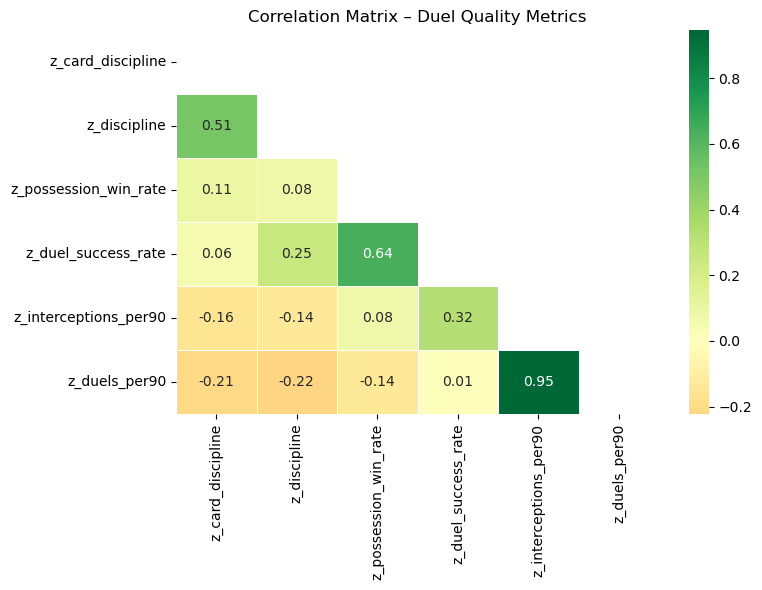

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = z_scores.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix – Duel Quality Metrics")
plt.tight_layout()
plt.show()

### Visualising Metric Distributions

Before combining metrics into a single score, it is useful to visualise how each normalised metric is distributed across all qualified players. This helps us spot outliers, check that z-scores look reasonable, and understand how spread out player performance is on each dimension. The custom `DistributionPlot` class overlays a highlighted marker for a specific player of interest.

In [63]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

metrics = [
    "z_card_discipline",
    "z_discipline",
    "z_possession_win_rate",
    "z_duel_success_rate",
    "z_interceptions_per90",
    "z_duels_per90"
]

# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns=metrics,
    labels=["Worse", "Average", "Above Average"]
)

# Add title
dist_plot.add_title(
    title="Center-Back Duel Quality Distirbution",
    subtitle=f"Based on {len(duel_summary)} players with ≥30 duels and >=350 minutes playing time"
)

# Convert z_scores to dataframe format expected by add_group_data
z_scores_df = z_scores.reset_index()

# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover="",
    hover_string=""
)

# Highlight specific player (player.id = 370)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover="",
        hover_string=""
    )

# For Jupyter notebooks, use this to display
dist_plot.fig.show()

## Quality Score

With all individual metrics normalised, we now aggregate them into a single composite **Duel Quality Index**. This index captures how well a center-back performs across all ground-duel dimensions — volume, success rate, possession recovery, and discipline — relative to all other qualifying center-backs in the dataset.

### Building the Composite Duel Quality Index

We combine all six normalised metrics into a single weighted score. The weights reflect the relative importance of each dimension: `possession_win_rate` receives the highest weight (35 %) because directly winning the ball back is the most valuable defensive outcome, while volume and discipline metrics play a supporting role. All weights sum to 1.0.

**This can be adapted based on our needs**

In [64]:
weights = {
    "z_duels_per90": 0.1,
    "z_interceptions_per90": 0.15,
    "z_duel_success_rate": 0.2,
    "z_possession_win_rate": 0.35,
    "z_discipline": 0.10,
    "z_card_discipline": 0.10
}

# Weighted sum: each metric's z-score is multiplied by its importance weight
duel_summary["Zq_raw"] = sum(
    z_scores[m] * w for m, w in weights.items()
)

### Normalising the Composite Score

The raw weighted sum (`Zq_raw`) already uses z-scored inputs, but its scale varies depending on the weights chosen. We re-standardise it to a final z-score (`duel_quality`) so that the output is always centred at 0 with a standard deviation of 1 — making it easy to compare players across seasons or leagues.

In [65]:
duel_summary["duel_quality"] = (
    (duel_summary["Zq_raw"] - duel_summary["Zq_raw"].mean())
) / duel_summary["Zq_raw"].std()

### Ranking Center-Backs by Duel Quality

We now sort all qualified center-backs by their composite `duel_quality` score in descending order to produce the final ranking. A higher z-score means the player performs better than the average of all center-backs on the overall duel quality index.

In [66]:
duel_summary

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,interceptions_per90,stops_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90,Zq_raw,duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,...,3.815789,2.342105,-0.386663,0.065808,-0.133224,0.172966,0.358165,0.312105,0.040815,0.06724
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,...,2.660496,1.558674,-0.841082,0.578173,0.13228,0.134523,-0.672726,-0.734444,-0.127442,-0.209954
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,...,3.000000,1.432432,0.603563,0.592629,1.739724,1.097894,-0.36978,-0.670054,0.825629,1.36018
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,...,3.216216,1.918919,0.030416,0.441599,-0.163482,-0.316928,-0.176846,-0.081379,-0.108067,-0.178035
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,...,3.027027,1.675676,0.603563,0.628477,0.690371,0.642876,-0.345663,-0.5355,0.38801,0.639226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520300,N. Wood,776.0,55,12,23,1,19,1,0,0.636364,0.218182,...,4.059278,2.667526,-1.313876,0.343196,-0.796258,-0.466372,0.575435,0.793529,-0.303365,-0.499777
653730,A. Khusanov,504.0,30,4,16,1,9,1,0,0.666667,0.133333,...,3.571429,2.857143,-2.911742,-0.45094,-2.053999,-0.029901,0.140117,0.157696,-1.024361,-1.68758
327391,J. Bree,490.0,40,5,19,0,16,0,0,0.600000,0.125000,...,4.408163,3.489796,0.603563,1.296158,-2.177527,-0.990138,0.886751,1.395974,-0.49758,-0.819736


In [67]:
cols = ["duel_quality"]
duel_summary.sort_values("duel_quality", ascending=False).head(15)

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,interceptions_per90,stops_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90,Zq_raw,duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
568412,J. Gvardiol,989.0,51,20,23,0,8,0,0,0.843137,0.392157,...,3.913043,2.093023,0.603563,1.296158,1.782639,2.511902,0.444946,-0.287938,1.354224,2.231013
349142,N. Mazraoui,856.0,104,33,39,3,29,0,0,0.692308,0.317308,...,7.570093,4.100467,0.603563,-0.215753,0.673122,0.339421,3.708203,3.628614,1.26135,2.078007
623641,E. Agbadou,1411.0,71,33,21,3,14,0,0,0.760563,0.464789,...,3.444366,1.339476,0.603563,-0.918473,2.859288,1.322545,0.026736,-0.357854,1.201994,1.980222
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,...,3.000000,1.432432,0.603563,0.592629,1.739724,1.097894,-0.36978,-0.670054,0.825629,1.36018
645877,Y. Mosquera,442.0,34,10,16,1,7,0,0,0.764706,0.294118,...,5.294118,3.257919,0.603563,-0.245399,0.329367,1.382212,1.677306,1.132199,0.792353,1.30536
412968,M. Senesi,1105.0,131,39,50,8,34,2,0,0.679389,0.297710,...,7.248869,4.072398,-1.0065,-1.904632,0.382617,0.15335,3.421568,3.463766,0.733085,1.207718
424806,E. Pinnock,1916.0,109,36,43,0,30,0,0,0.724771,0.330275,...,3.710856,2.019833,0.603563,1.296158,0.865344,0.807003,0.264531,0.010144,0.694937,1.144873
583655,C. Okoli,1134.0,86,26,38,2,20,1,0,0.744186,0.302326,...,5.079365,3.015873,-0.622706,0.077253,0.451036,1.086653,1.485678,1.071411,0.650641,1.071897
283145,T. Adarabioyo,1377.0,68,24,24,0,20,0,0,0.705882,0.352941,...,3.137255,1.568627,0.603563,1.296158,1.20133,0.534944,-0.247305,-0.410289,0.639302,1.053216


In [68]:
duel_summary.sort_values("z_duels_per90", ascending=False).head(15)

,,minutes,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,interceptions_per90,stops_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90,Zq_raw,duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
349142,N. Mazraoui,856.0,104,33,39,3,29,0,0,0.692308,0.317308,...,7.570093,4.100467,0.603563,-0.215753,0.673122,0.339421,3.708203,3.628614,1.26135,2.078007
412968,M. Senesi,1105.0,131,39,50,8,34,2,0,0.679389,0.297710,...,7.248869,4.072398,-1.0065,-1.904632,0.382617,0.15335,3.421568,3.463766,0.733085,1.207718
402884,K. Walker-Peters,360.0,41,3,19,2,17,1,0,0.536585,0.073171,...,5.500000,4.750000,-1.968611,-1.26057,-2.945811,-1.903533,1.861019,3.202591,-1.135247,-1.87026
327391,J. Bree,490.0,40,5,19,0,16,0,0,0.600000,0.125000,...,4.408163,3.489796,0.603563,1.296158,-2.177527,-0.990138,0.886751,1.395974,-0.49758,-0.819736
534563,C. Richards,1967.0,160,48,61,3,48,0,0,0.681250,0.300000,...,4.987290,2.791052,0.603563,0.313416,0.416563,0.180151,1.403518,1.379703,0.622023,1.024751
364003,S. Bueno,1676.0,134,32,58,6,38,0,0,0.671642,0.238806,...,4.832936,3.114558,0.603563,-1.05069,-0.490539,0.041759,1.265784,1.301859,0.112004,0.184521
645877,Y. Mosquera,442.0,34,10,16,1,7,0,0,0.764706,0.294118,...,5.294118,3.257919,0.603563,-0.245399,0.329367,1.382212,1.677306,1.132199,0.792353,1.30536
583655,C. Okoli,1134.0,86,26,38,2,20,1,0,0.744186,0.302326,...,5.079365,3.015873,-0.622706,0.077253,0.451036,1.086653,1.485678,1.071411,0.650641,1.071897
501419,J. Todibo,1829.0,137,29,73,2,33,0,0,0.744526,0.211679,...,5.019136,3.592127,0.603563,0.531006,-0.892654,1.091543,1.431934,1.019132,0.33604,0.553608


In [69]:
duel_summary["duel_quality"] \
    .sort_values(ascending=False) \
    .head(15)

player.id  player.name  
568412     J. Gvardiol      2.231013
349142     N. Mazraoui      2.078007
623641     E. Agbadou       1.980222
370        V. van Dijk       1.36018
645877     Y. Mosquera       1.30536
412968     M. Senesi        1.207718
424806     E. Pinnock       1.144873
583655     C. Okoli         1.071897
283145     T. Adarabioyo    1.053216
534563     C. Richards      1.024751
400549     Pau Torres       0.970251
590703     I. Zabarnyi      0.945072
447424     C. Bassey        0.942461
346131     T. Chalobah      0.930086
240032     J. Bednarek      0.887905
Name: duel_quality, dtype: object

In [70]:
duel_summary.columns

Index(['minutes', 'total_duels', 'won_possession', 'stopped_progress', 'foul',
       'lost_duel', 'yellow_cards', 'red_cards', 'duel_success_rate',
       'possession_win_rate', 'foul_rate', 'discipline', 'card_discipline',
       'duels_per90', 'interceptions_per90', 'stops_per90',
       'z_card_discipline', 'z_discipline', 'z_possession_win_rate',
       'z_duel_success_rate', 'z_interceptions_per90', 'z_duels_per90',
       'Zq_raw', 'duel_quality'],
      dtype='str')

In [71]:
ground_duels_cols = [
    "minutes", "total_duels", "yellow_cards", "red_cards",
    "duel_success_rate", "possession_win_rate", "discipline", "card_discipline",
    "duels_per90", "interceptions_per90",
    "z_duel_success_rate", "z_possession_win_rate", "z_discipline",
    "z_card_discipline", "z_duels_per90", "z_interceptions_per90",
    "duel_quality"
]
df_ground_duels = duel_summary[ground_duels_cols].reset_index()

In [72]:
file_name = "ground_duels.csv"
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "PL", "Qualities", file_name)

df_ground_duels.to_csv(path, index=True)

## Aerial Duels

Aerial duel ability is the second defensive quality dimension we aim to measure. Here we explore the `aerialDuel.*` fields available in the Wyscout event data to understand how to extract and structure aerial contest information for center-backs. **Note:** this section is exploratory and the full aerial metric pipeline is in progress.

In [73]:
print (cb_events["aerialDuel.firstTouch"].unique())
print (cb_events["aerialDuel.height"].unique())


[nan False True]
[ nan 191. 181. 187. 180. 185. 183. 182. 190. 192. 195. 189. 199. 184.
 188. 194. 193.   0. 178. 198. 196. 186. 197. 172. 179. 175. 177. 173.
 170. 174.]


In [74]:
cb_events.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'possession.attack.withShot', 'possession.attack.withShotOnGoal',
       'possession.

'aerialDuel.opponent.id',
       'aerialDuel.opponent.name', 'aerialDuel.opponent.position',
       'aerialDuel.opponent.height', 'aerialDuel.firstTouch',
       'aerialDuel.height', 'aerialDuel.relatedDuelId','infraction.opponent',
       'aerialDuel.opponent'],

In [75]:
aerial_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "infraction.type",
    'aerialDuel.opponent.id',
    'aerialDuel.opponent.name', 'aerialDuel.opponent.position',
    'aerialDuel.opponent.height', 'aerialDuel.firstTouch',
    'aerialDuel.height', 'aerialDuel.relatedDuelId','infraction.opponent',
    'aerialDuel.opponent',
]

aerial_duels = cb_events[
    (cb_events["aerialDuel.firstTouch"].notna()) | (cb_events["infraction.type"] == 'regular_foul')
]
aerial_duels

aerial_duels[aerial_cols].head(50)

,player.id,player.name,matchTimestamp,infraction.type,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,infraction.opponent,aerialDuel.opponent
393,9380,J. Stones,00:22:09.414,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
437,545267,R. Drăgușin,00:24:27.024,NaN,71654.0,Ederson,GK,188.0,False,191.0,2.384314e+09,NaN,NaN
768,136441,B. Davies,00:41:59.513,NaN,427097.0,E. Haaland,CF,195.0,False,181.0,2.384314e+09,NaN,NaN
788,136441,B. Davies,00:42:33.866,NaN,447205.0,P. Foden,RWF,171.0,True,181.0,2.384314e+09,NaN,NaN
822,297957,M. Akanji,00:44:30.895,NaN,551442.0,Pedro Porro,RB,173.0,True,187.0,2.384315e+09,NaN,NaN
958,297957,M. Akanji,00:48:35.157,NaN,286831.0,D. Solanke,CF,187.0,True,187.0,2.384315e+09,NaN,NaN
997,297957,M. Akanji,00:50:16.453,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1070,134102,N. Aké,00:55:24.835,NaN,472363.0,D. Kulusevski,RWF,186.0,False,180.0,2.384315e+09,NaN,NaN
1209,134102,N. Aké,01:01:45.252,NaN,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN
1231,134102,N. Aké,01:03:16.424,NaN,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN


In [76]:
# Work on a copy so the original ground_duels DataFrame is preserved
aerial_duels_with_fouls = aerial_duels.copy()

aerial_duels_with_fouls["next_event_foul"] = (
    aerial_duels["infraction.type"].shift(-1) == "regular_foul"
)

aerial_duels_with_fouls["next_player_same"] = (
    aerial_duels["player.id"] == aerial_duels["player.id"].shift(-1)
)

aerial_duels_with_fouls["foul_timestamp_seconds"] = aerial_duels["matchTimestamp"].apply(timestamp_to_seconds).shift(-1)
aerial_duels_with_fouls["match_timestamp_seconds"] = aerial_duels["matchTimestamp"].apply(timestamp_to_seconds)

aerial_duels_with_fouls["time_diff"] = (
    aerial_duels_with_fouls["foul_timestamp_seconds"] - aerial_duels_with_fouls["match_timestamp_seconds"]
)

aerial_duels_with_fouls["yellowCard_shift"] = aerial_duels_with_fouls["infraction.yellowCard"].shift(-1)
aerial_duels_with_fouls["redCard_shift"] = aerial_duels_with_fouls["infraction.redCard"].shift(-1)

aerial_duels_with_fouls["duel_resulted_foul"] = (
    aerial_duels_with_fouls["next_event_foul"] &
    aerial_duels_with_fouls["next_player_same"] &
    (aerial_duels_with_fouls["time_diff"] <= 1.3)
)

aerial_duels_with_fouls["yellowCard"] = aerial_duels_with_fouls["yellowCard_shift"].where(
    aerial_duels_with_fouls["duel_resulted_foul"],
    False
)

aerial_duels_with_fouls["redCard"] = aerial_duels_with_fouls["redCard_shift"].where(
    aerial_duels_with_fouls["duel_resulted_foul"],
    False
)

# Drop rows where infraction.type is regular_foul
aerial_duels_with_fouls = aerial_duels_with_fouls[aerial_duels_with_fouls["infraction.type"] != "regular_foul"]

# After the duel_resulted_foul flag
aerial_duels_with_fouls["unsuccessful_duel"] = (
    ~aerial_duels_with_fouls["duel_resulted_foul"] &
    (aerial_duels_with_fouls["aerialDuel.firstTouch"] == False)
)

aerial_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "relatedEventId",
    "infraction.type",
    "yellowCard",
    "redCard",
    "duel_resulted_foul",
    'aerialDuel.opponent.id',
    'aerialDuel.opponent.name', 'aerialDuel.opponent.position',
    'aerialDuel.opponent.height', 'aerialDuel.firstTouch',
    'aerialDuel.height', 'aerialDuel.relatedDuelId','infraction.opponent',
    'aerialDuel.opponent',
    "unsuccessful_duel"
]

aerial_duels_with_fouls[aerial_cols].head(20)

,player.id,player.name,matchTimestamp,relatedEventId,infraction.type,yellowCard,redCard,duel_resulted_foul,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,infraction.opponent,aerialDuel.opponent,unsuccessful_duel
437,545267,R. Drăgușin,00:24:27.024,2.384314e+09,NaN,False,False,False,71654.0,Ederson,GK,188.0,False,191.0,2.384314e+09,NaN,NaN,True
768,136441,B. Davies,00:41:59.513,2.384314e+09,NaN,False,False,False,427097.0,E. Haaland,CF,195.0,False,181.0,2.384314e+09,NaN,NaN,True
788,136441,B. Davies,00:42:33.866,2.384314e+09,NaN,False,False,False,447205.0,P. Foden,RWF,171.0,True,181.0,2.384314e+09,NaN,NaN,False
822,297957,M. Akanji,00:44:30.895,2.384314e+09,NaN,False,False,False,551442.0,Pedro Porro,RB,173.0,True,187.0,2.384315e+09,NaN,NaN,False
958,297957,M. Akanji,00:48:35.157,2.384314e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,187.0,2.384315e+09,NaN,NaN,False
1070,134102,N. Aké,00:55:24.835,2.384314e+09,NaN,False,False,False,472363.0,D. Kulusevski,RWF,186.0,False,180.0,2.384315e+09,NaN,NaN,True
1209,134102,N. Aké,01:01:45.252,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False
1231,134102,N. Aké,01:03:16.424,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False
1292,545267,R. Drăgușin,01:06:11.205,2.384315e+09,NaN,False,False,False,0.0,NaN,NaN,NaN,True,191.0,2.384316e+09,NaN,NaN,False
1414,134102,N. Aké,01:12:31.760,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False


In [77]:
print(aerial_duels_with_fouls["duel_resulted_foul"].unique())
print(aerial_duels_with_fouls["yellowCard"].unique())
print(aerial_duels_with_fouls["aerialDuel.opponent"].unique())
print(aerial_duels_with_fouls["infraction.type"].unique())
print(aerial_duels_with_fouls["unsuccessful_duel"].unique())

[False  True]
[False True]
[nan]
<ArrowStringArray>
[nan]
Length: 1, dtype: str
[ True False]


In [78]:
aerial_duels_with_fouls[aerial_cols]

,player.id,player.name,matchTimestamp,relatedEventId,infraction.type,yellowCard,redCard,duel_resulted_foul,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,infraction.opponent,aerialDuel.opponent,unsuccessful_duel
437,545267,R. Drăgușin,00:24:27.024,2.384314e+09,NaN,False,False,False,71654.0,Ederson,GK,188.0,False,191.0,2.384314e+09,NaN,NaN,True
768,136441,B. Davies,00:41:59.513,2.384314e+09,NaN,False,False,False,427097.0,E. Haaland,CF,195.0,False,181.0,2.384314e+09,NaN,NaN,True
788,136441,B. Davies,00:42:33.866,2.384314e+09,NaN,False,False,False,447205.0,P. Foden,RWF,171.0,True,181.0,2.384314e+09,NaN,NaN,False
822,297957,M. Akanji,00:44:30.895,2.384314e+09,NaN,False,False,False,551442.0,Pedro Porro,RB,173.0,True,187.0,2.384315e+09,NaN,NaN,False
958,297957,M. Akanji,00:48:35.157,2.384314e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,187.0,2.384315e+09,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630149,590874,Toti,01:32:28.200,2.395401e+09,NaN,False,False,False,0.0,NaN,NaN,NaN,False,187.0,2.395401e+09,NaN,NaN,True
630203,501419,J. Todibo,01:35:38.945,2.395401e+09,NaN,False,False,False,29640.0,M. Lemina,LCMF3,184.0,False,190.0,2.395401e+09,NaN,NaN,True
630208,590874,Toti,01:36:12.790,2.395401e+09,NaN,False,False,False,285403.0,T. Souček,RCMF,192.0,True,187.0,2.395401e+09,NaN,NaN,False
630242,590874,Toti,01:37:59.493,2.395401e+09,NaN,False,False,False,340706.0,G. Rodríguez,LCMF,185.0,True,187.0,2.395401e+09,NaN,NaN,False


In [79]:
aerial_duels_with_fouls[aerial_duels_with_fouls["aerialDuel.relatedDuelId"] == 2364272638][aerial_cols]

,player.id,player.name,matchTimestamp,relatedEventId,infraction.type,yellowCard,redCard,duel_resulted_foul,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,infraction.opponent,aerialDuel.opponent,unsuccessful_duel
2152,415847,C. Romero,00:21:21.841,2.364273e+09,NaN,False,False,False,412027.0,E. Konsa,RCB,183.0,False,185.0,2.364273e+09,NaN,NaN,True


In [80]:
print(aerial_duels_with_fouls[aerial_duels_with_fouls["player.name"] == "E. Konsa"][aerial_cols])

        player.id player.name matchTimestamp  relatedEventId infraction.type  \
2153       412027    E. Konsa   00:21:21.841    2.364273e+09             NaN   
26656      412027    E. Konsa   01:32:30.562    2.524875e+09             NaN   
86522      412027    E. Konsa   00:14:38.868    2.411681e+09             NaN   
87823      412027    E. Konsa   01:27:44.073    2.411682e+09             NaN   
100509     412027    E. Konsa   00:19:17.571    2.537794e+09             NaN   
100808     412027    E. Konsa   00:36:01.678    2.537794e+09             NaN   
100868     412027    E. Konsa   00:38:30.710    2.537794e+09             NaN   
100987     412027    E. Konsa   00:45:55.027    2.537795e+09             NaN   
101498     412027    E. Konsa   01:23:37.634    2.537794e+09             NaN   
112527     412027    E. Konsa   00:36:44.566    2.438324e+09             NaN   
112864     412027    E. Konsa   00:55:51.081    2.438326e+09             NaN   
113455     412027    E. Konsa   01:32:54

In [81]:
aerial_duels_with_fouls[aerial_duels_with_fouls["duel_resulted_foul"] & aerial_duels_with_fouls["aerialDuel.firstTouch"]]

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,next_player_same,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel


### Aerial Duels Metrics 

In [82]:
def aerial_classify_duel(row):

    if row["duel_resulted_foul"]:
        return "foul"

    if row["unsuccessful_duel"]:
        return "lost_duel"
    elif not row["unsuccessful_duel"]:
        return "won_duel" 

    return "other"

aerial_duels_with_fouls["duel_outcome"] = aerial_duels_with_fouls.apply(aerial_classify_duel, axis=1)

In [83]:
aerial_duels_with_fouls[aerial_cols].head(20)

,player.id,player.name,matchTimestamp,relatedEventId,infraction.type,yellowCard,redCard,duel_resulted_foul,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,infraction.opponent,aerialDuel.opponent,unsuccessful_duel
437,545267,R. Drăgușin,00:24:27.024,2.384314e+09,NaN,False,False,False,71654.0,Ederson,GK,188.0,False,191.0,2.384314e+09,NaN,NaN,True
768,136441,B. Davies,00:41:59.513,2.384314e+09,NaN,False,False,False,427097.0,E. Haaland,CF,195.0,False,181.0,2.384314e+09,NaN,NaN,True
788,136441,B. Davies,00:42:33.866,2.384314e+09,NaN,False,False,False,447205.0,P. Foden,RWF,171.0,True,181.0,2.384314e+09,NaN,NaN,False
822,297957,M. Akanji,00:44:30.895,2.384314e+09,NaN,False,False,False,551442.0,Pedro Porro,RB,173.0,True,187.0,2.384315e+09,NaN,NaN,False
958,297957,M. Akanji,00:48:35.157,2.384314e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,187.0,2.384315e+09,NaN,NaN,False
1070,134102,N. Aké,00:55:24.835,2.384314e+09,NaN,False,False,False,472363.0,D. Kulusevski,RWF,186.0,False,180.0,2.384315e+09,NaN,NaN,True
1209,134102,N. Aké,01:01:45.252,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False
1231,134102,N. Aké,01:03:16.424,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False
1292,545267,R. Drăgușin,01:06:11.205,2.384315e+09,NaN,False,False,False,0.0,NaN,NaN,NaN,True,191.0,2.384316e+09,NaN,NaN,False
1414,134102,N. Aké,01:12:31.760,2.384315e+09,NaN,False,False,False,286831.0,D. Solanke,CF,187.0,True,180.0,2.384315e+09,NaN,NaN,False


In [84]:
aerial_duel_summary = (
    aerial_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_outcome"] 
    .value_counts()
    .unstack(fill_value=0)
)
aerial_duel_summary["total_duels"] = aerial_duel_summary.sum(axis=1)
aerial_duel_summary = aerial_duel_summary[
    [ "won_duel", "lost_duel", "foul", "total_duels"]
]
aerial_duel_summary

,duel_outcome,won_duel,lost_duel,foul,total_duels
player.id,player.name,,,,
370,V. van Dijk,135,52,0,187
1712,K. Tete,1,1,0,2
7914,J. Evans,11,3,0,14
7919,M. Keane,40,22,0,62
7953,C. Coady,16,21,0,37
...,...,...,...,...,...
777938,Dean Huijsen,74,52,1,127
783644,J. Simpson-Pusey,1,2,0,3
816274,J. Sanda,0,1,0,1


In [85]:
aerial_duel_summary = aerial_duel_summary.reset_index().merge(
    minutes_per_player,
    left_on="player.id",
    right_on="player_id",
    how="left"
).set_index(["player.id", "player.name"])

# Reorder columns to put minutes first
cols = ["minutes"] + [col for col in aerial_duel_summary.columns if col != "minutes" and col != "player_id"]
aerial_duel_summary = aerial_duel_summary[cols]

In [86]:
# Calculate duel success rate
aerial_duel_summary["aerial_duel_success_rate"] = (
    aerial_duel_summary["won_duel"] / aerial_duel_summary["total_duels"]
)

# Calculate foul rate and discipline
# aerial_duel_summary["foul_rate"] = aerial_duel_summary["foul"] / aerial_duel_summary["total_duels"]
# aerial_duel_summary["discipline"] = 1 - aerial_duel_summary["foul_rate"]

In [87]:
aerial_duel_summary[aerial_duel_summary["foul"] > 0]

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate
player.id,player.name,,,,,,
145787,J. Andersen,2700.0,85,51,1,137,0.620438
234399,A. Webster,885.0,26,11,1,38,0.684211
239411,T. Mings,1115.0,35,25,1,61,0.573770
255738,J. Lerma,493.0,12,6,1,19,0.631579
283145,T. Adarabioyo,1377.0,41,29,1,71,0.577465
297957,M. Akanji,1969.0,32,38,1,71,0.450704
365443,M. de Ligt,2123.0,57,35,1,93,0.612903
397074,M. Guéhi,2970.0,81,73,1,155,0.522581
424241,N. Milenković,3330.0,100,54,1,155,0.645161


## Volume Metrics

Rate metrics (success rates, discipline) tell us *how well* a player performs in duels, but not *how often* they get involved. Volume metrics capture duel frequency and interception activity per 90 minutes, adding an activity dimension to the quality profile.

### Per-90 Volume Metrics

Raw counts (e.g. total duels) are biased towards players who played more minutes. To make comparisons fair, we normalise volume statistics to a **per-90-minute** basis: dividing by total minutes played and multiplying by 90. This tells us how active and impactful a player is relative to their playing time.

In [88]:
aerial_duel_summary["aerial_duels_per90"] = aerial_duel_summary["total_duels"] / aerial_duel_summary["minutes"] * 90
aerial_duel_summary["aerial_won_duel_per90"] = aerial_duel_summary["won_duel"] / aerial_duel_summary["minutes"] * 90

In [89]:
aerial_duel_summary

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate,aerial_duels_per90,aerial_won_duel_per90
player.id,player.name,,,,,,,,
370,V. van Dijk,3330.0,135,52,0,187,0.721925,5.054054,3.648649
1712,K. Tete,85.0,1,1,0,2,0.500000,2.117647,1.058824
7914,J. Evans,300.0,11,3,0,14,0.785714,4.200000,3.300000
7919,M. Keane,1046.0,40,22,0,62,0.645161,5.334608,3.441683
7953,C. Coady,1714.0,16,21,0,37,0.432432,1.942824,0.840140
...,...,...,...,...,...,...,...,...,...
777938,Dean Huijsen,2424.0,74,52,1,127,0.582677,4.715347,2.747525
783644,J. Simpson-Pusey,97.0,1,2,0,3,0.333333,2.783505,0.927835
816274,J. Sanda,12.0,0,1,0,1,0.000000,7.500000,0.000000


In [90]:
# Show all rows that contain any NaN values
aerial_duel_summary[aerial_duel_summary.isna().any(axis=1)]

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate,aerial_duels_per90,aerial_won_duel_per90
player.id,player.name,,,,,,,,
217031,T. Partey,NaN,1,1,0,2,0.5,NaN,NaN
285403,T. Souček,NaN,1,0,0,1,1.0,NaN,NaN
302518,L. Cook,NaN,0,1,0,1,0.0,NaN,NaN
361807,R. Bentancur,NaN,0,1,0,1,0.0,NaN,NaN
368225,T. Adams,NaN,1,1,0,2,0.5,NaN,NaN
383569,A. Robinson,NaN,0,1,0,1,0.0,NaN,NaN
412034,J. Justin,NaN,1,0,0,1,1.0,NaN,NaN
491413,D. Muñoz,NaN,2,2,0,4,0.5,NaN,NaN
579007,K. McAteer,0.0,0,1,0,1,0.0,inf,NaN


### Applying Minimum Playing-Time and Volume Thresholds

Players with very few duels or limited minutes can produce extreme, unreliable metric values. We remove rows with missing data and apply two minimum thresholds: **≥ 30 total duels** and **≥ 350 minutes played**. This ensures only players with a meaningful sample size are included in the quality ranking.

In [91]:
aerial_duel_summary.dropna(inplace=True)
aerial_duel_summary

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate,aerial_duels_per90,aerial_won_duel_per90
player.id,player.name,,,,,,,,
370,V. van Dijk,3330.0,135,52,0,187,0.721925,5.054054,3.648649
1712,K. Tete,85.0,1,1,0,2,0.500000,2.117647,1.058824
7914,J. Evans,300.0,11,3,0,14,0.785714,4.200000,3.300000
7919,M. Keane,1046.0,40,22,0,62,0.645161,5.334608,3.441683
7953,C. Coady,1714.0,16,21,0,37,0.432432,1.942824,0.840140
...,...,...,...,...,...,...,...,...,...
777938,Dean Huijsen,2424.0,74,52,1,127,0.582677,4.715347,2.747525
783644,J. Simpson-Pusey,97.0,1,2,0,3,0.333333,2.783505,0.927835
816274,J. Sanda,12.0,0,1,0,1,0.000000,7.500000,0.000000


In [92]:
aerial_duel_summary_filt = aerial_duel_summary[aerial_duel_summary["total_duels"] >= 10]
aerial_duel_summary_filt = aerial_duel_summary_filt[aerial_duel_summary_filt["minutes"] >= 300]

In [93]:
aerial_duel_summary_filt

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate,aerial_duels_per90,aerial_won_duel_per90
player.id,player.name,,,,,,,,
370,V. van Dijk,3330.0,135,52,0,187,0.721925,5.054054,3.648649
7914,J. Evans,300.0,11,3,0,14,0.785714,4.200000,3.300000
7919,M. Keane,1046.0,40,22,0,62,0.645161,5.334608,3.441683
7953,C. Coady,1714.0,16,21,0,37,0.432432,1.942824,0.840140
8136,J. Stephens,1455.0,9,12,0,21,0.428571,1.298969,0.556701
...,...,...,...,...,...,...,...,...,...
645877,Y. Mosquera,442.0,12,3,0,15,0.800000,3.054299,2.443439
653730,A. Khusanov,504.0,11,3,0,14,0.785714,2.500000,1.964286
767087,A. Gray,924.0,11,10,0,21,0.523810,2.045455,1.071429


### Normalising Metrics with Z-Scores

Each metric is on a different scale (e.g. a rate between 0–1 vs. duels per 90 minutes). To combine them fairly into a composite score, we standardise every metric to a z-score: subtract the mean and divide by the standard deviation across all qualifying players. A z-score of 0 means average, +1 means one standard deviation above average.

In [94]:
metrics = [
    "aerial_duel_success_rate",
    "aerial_duels_per90",
    "aerial_won_duel_per90"
]

# Standardise: subtract column mean, divide by column std → z-score
z_scores = (aerial_duel_summary_filt[metrics] - aerial_duel_summary_filt[metrics].mean()) / aerial_duel_summary_filt[metrics].std()

# Rename columns to z_ prefix (e.g. card_discipline → z_card_discipline)
z_scores.columns = ["z_" + col for col in z_scores.columns]

In [95]:
z_scores

,,z_aerial_duel_success_rate,z_aerial_duels_per90,z_aerial_won_duel_per90
player.id,player.name,,,
370,V. van Dijk,1.519223,1.057783,1.888824
7914,J. Evans,2.176987,0.346513,1.439700
7919,M. Keane,0.727670,1.291433,1.622213
7953,C. Coady,-1.465891,-1.533298,-1.729055
8136,J. Stephens,-1.505704,-2.069511,-2.094177
...,...,...,...,...
645877,Y. Mosquera,2.324294,-0.607645,0.336291
653730,A. Khusanov,2.176987,-1.069273,-0.280947
767087,A. Gray,-0.523653,-1.447826,-1.431112


In [96]:
# Add all z-scored metric columns into aerial_duel_summary_filt
# z_scores shares the same index as duel_summary, so join aligns automatically
aerial_duel_summary_filt = aerial_duel_summary_filt.join(z_scores)

In [97]:
aerial_duel_summary_filt

,,minutes,won_duel,lost_duel,foul,total_duels,aerial_duel_success_rate,aerial_duels_per90,aerial_won_duel_per90,z_aerial_duel_success_rate,z_aerial_duels_per90,z_aerial_won_duel_per90
player.id,player.name,,,,,,,,,,,
370,V. van Dijk,3330.0,135,52,0,187,0.721925,5.054054,3.648649,1.519223,1.057783,1.888824
7914,J. Evans,300.0,11,3,0,14,0.785714,4.200000,3.300000,2.176987,0.346513,1.439700
7919,M. Keane,1046.0,40,22,0,62,0.645161,5.334608,3.441683,0.727670,1.291433,1.622213
7953,C. Coady,1714.0,16,21,0,37,0.432432,1.942824,0.840140,-1.465891,-1.533298,-1.729055
8136,J. Stephens,1455.0,9,12,0,21,0.428571,1.298969,0.556701,-1.505704,-2.069511,-2.094177
...,...,...,...,...,...,...,...,...,...,...,...,...
645877,Y. Mosquera,442.0,12,3,0,15,0.800000,3.054299,2.443439,2.324294,-0.607645,0.336291
653730,A. Khusanov,504.0,11,3,0,14,0.785714,2.500000,1.964286,2.176987,-1.069273,-0.280947
767087,A. Gray,924.0,11,10,0,21,0.523810,2.045455,1.071429,-0.523653,-1.447826,-1.431112


### Metric Correlation Analysis

Before compositing the metrics into a quality index, we examine the correlation between them. High correlations between two metrics would mean they carry redundant information, which could over-weight a particular aspect of performance. The lower-triangle heatmap shows pairwise Pearson correlations across all qualified players.

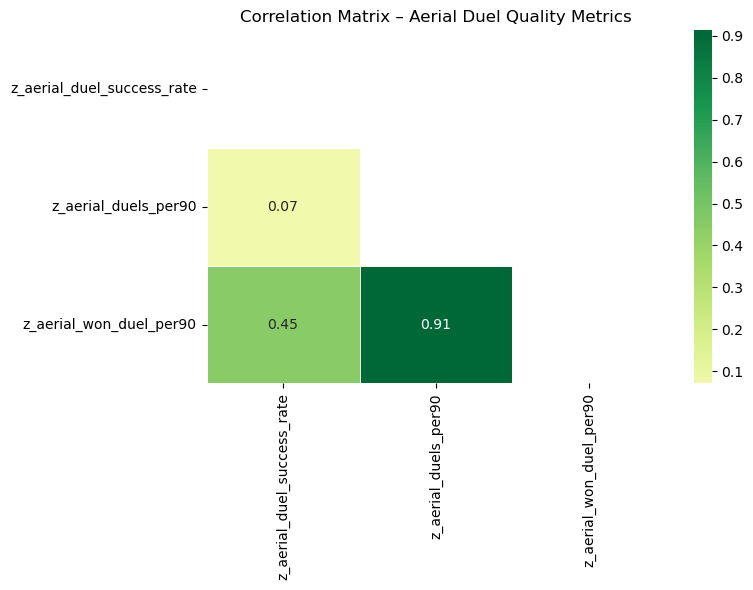

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = z_scores.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix – Aerial Duel Quality Metrics")
plt.tight_layout()
plt.show()

In [99]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

metrics = [
    "z_aerial_duel_success_rate",
    "z_aerial_duels_per90",
    "z_aerial_won_duel_per90",
]

# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns=metrics,
    labels=["Worse", "Average", "Above Average"]
)

# Add title
dist_plot.add_title(
    title="Center-Back Aerial Duel Quality Distribution",
    subtitle=f"Based on {len(aerial_duel_summary_filt)} players with ≥10 duels and >=300 minutes playing time"
)

# Convert z_scores to dataframe format expected by add_group_data
z_scores_df = z_scores.reset_index()

# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover="",
    hover_string=""
)

# Highlight specific player (player.id = 370)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover="",
        hover_string=""
    )

# For Jupyter notebooks, use this to display
dist_plot.fig.show()

### Quality Score

With all individual metrics normalised, we now aggregate them into a single composite **Aerial Duel Quality Index**. This index captures how well a center-back performs across all aerial-duel dimensions — volume, success rate— relative to all other qualifying center-backs in the dataset.

#### Building the Composite Duel Quality Index

We combine all three normalised metrics into a single weighted score. The weights reflect the relative importance of each dimension: `z_aerial_duel_success_rate` receives the highest weight (40 %) 

**This can be adapted based on our needs**

In [100]:
weights = {
    "z_aerial_duels_per90": 0.25,
    "z_aerial_duel_success_rate": 0.40,
    "z_aerial_won_duel_per90": 0.35,
}

# Weighted sum: each metric's z-score is multiplied by its importance weight
aerial_duel_summary_filt["Zq_raw"] = sum(
    z_scores[m] * w for m, w in weights.items()
)

### Normalising the Composite Score

The raw weighted sum (`Zq_raw`) already uses z-scored inputs, but its scale varies depending on the weights chosen. We re-standardise it to a final z-score (`duel_quality`) so that the output is always centred at 0 with a standard deviation of 1 — making it easy to compare players across seasons or leagues.

In [101]:
aerial_duel_summary_filt["aerial_duel_quality"] = (
    (aerial_duel_summary_filt["Zq_raw"] - aerial_duel_summary_filt["Zq_raw"].mean())
) / aerial_duel_summary_filt["Zq_raw"].std()

In [102]:
aerial_duel_summary_filt["aerial_duel_quality"] \
    .sort_values(ascending=False) \
    .head(15)

player.id  player.name 
370        V. van Dijk     1.909810
192792     D. Burn         1.852853
7914       J. Evans        1.820244
620468     J. Greaves      1.622056
9433       J. Tarkowski    1.521101
424806     E. Pinnock      1.483697
7919       M. Keane        1.471947
399581     D. O'Shea       1.452054
475597     S. Botman       1.252430
479155     N. Collins      1.234895
386292     A. Disasi       1.205343
136441     B. Davies       1.175421
645877     Y. Mosquera     1.115461
496001     M. Kilman       1.024720
590781     J. van Hecke    0.919232
Name: aerial_duel_quality, dtype: float64

# Ball Playing Quality

## Ball Playing Risk

### Objective

We build a **Ball-Playing Risk** metric for defenders and midfielders.

The central question is: *how much expected threat does a player generate for the opposition through passes made from their own half — either because those passes fail, or because the positions they pass from are inherently dangerous?*

The workflow is:
1. **Filter** passes that start in the team's own half (danger zone).
2. **Engineer** geometric features: pass distance, angle, start/end coordinates, subtype flags.
3. **Model** the probability that each pass will be completed.
4. **Combine** `(1 − p_success)` with a reversed xT grid to estimate the threat handed to the opposition when a pass goes astray.
5. **Aggregate** to player-level per-90 and per-pass summaries.

> **Note on the reference approach:** The original notebook defined a circular target (`danger_zone_score = w₁ × pass_success_rate − w₂ × dangerous_ball_lost`), then trained a regression model to predict it from those same inputs.  Here we use `pass.accurate` directly as the binary model target — no circularity.

In [103]:
cb_events

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,aerialDuel.opponent.height,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,aerialDuel.opponent,groundDuel.opponent
4,2384313775,5588197,1H,0,10,00:00:10.769,11.769625,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2384313788,5588197,1H,1,16,00:01:16.843,77.84337,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2384313576,5588197,1H,1,17,00:01:17.539,78.539811,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,2384313792,5588197,1H,1,32,00:01:32.625,93.625916,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2384313794,5588197,1H,1,39,00:01:39.547,100.547743,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630244,2395400792,5588229,2H,98,4,01:38:04.346,5965.346795,2.395401e+09,NaN,NaN,...,185.0,True,187.0,2.395401e+09,NaN,NaN,NaN,NaN,NaN,NaN
630246,2395400793,5588229,2H,98,6,01:38:06.058,5967.058901,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630248,2395400794,5588229,2H,98,10,01:38:10.693,5971.693504,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630252,2395400930,5588229,2H,98,22,01:38:22.427,5983.42787,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Imports

In [104]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[0]))

from utils.pass_risk import (
    XT_GRID,
    get_own_half_passes,
    calculate_pass_features,
    prepare_pass_features,
    train_pass_success_model,
    predict_pass_probability,
    calculate_xt_risk,
    aggregate_player_risk_metrics,
    DEFAULT_FEATURE_COLS,
)

### Data

We reuse the DataFrames already loaded earlier in this notebook:

| Variable | Contents |
|---|---|
| `events_df` | All 2024-25 PL events (Wyscout format, one row per event) |
| `players_england_df` | Player metadata: `player_id`, `short_name`, `role` |
| `minutes_england_df` | Playing time per player per match |

The Ball-Playing section does **not** reload any files — it works directly on what is already in memory.

### 1 · Filter Own-Half Passes

We keep only passes where the ball starts in the team's own half (`location.x < 50` on the 0–100 Wyscout coordinate scale).  These are the passes where a mistake is most costly — giving the opponent possession close to your goal.

A `Successful` column (1 = accurate, 0 = inaccurate) is added directly from `pass.accurate`.

In [105]:
own_half_passes = get_own_half_passes(cb_events, x_threshold=50)

print(f"Own-half passes: {len(own_half_passes):,}")
print(f"Pass accuracy:   {own_half_passes['Successful'].mean():.1%}")
own_half_passes[["player.id", "player.name", "location.x", "location.y",
                 "pass.accurate", "Successful"]].head()

Own-half passes: 66,067
Pass accuracy:   89.6%


,player.id,player.name,location.x,location.y,pass.accurate,Successful
0,136441,B. Davies,34.0,32.0,True,1
1,136441,B. Davies,12.0,31.0,False,0
2,136441,B. Davies,9.0,16.0,True,1
3,136441,B. Davies,16.0,28.0,True,1
4,545267,R. Drăgușin,32.0,93.0,True,1


In [106]:
passes = cb_events[cb_events["type.primary"] == "pass"].copy()
passes = passes[passes["location.x"] < 50].copy()

# Pass success comes directly from pass.accurate — no circular target.
passes["Successful"] = passes["pass.accurate"].astype(int)

passes["pass.height"] = passes["pass.height"].fillna("low")

In [107]:
passes.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'possession.attack.withShot', 'possession.attack.withShotOnGoal',
       'possession.

In [108]:
passes

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,aerialDuel.firstTouch,aerialDuel.height,aerialDuel.relatedDuelId,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,aerialDuel.opponent,groundDuel.opponent,Successful
4,2384313775,5588197,1H,0,10,00:00:10.769,11.769625,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
16,2384313792,5588197,1H,1,32,00:01:32.625,93.625916,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
21,2384313796,5588197,1H,1,44,00:01:44.111,105.111376,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
26,2384313800,5588197,1H,2,1,00:02:01.466,122.466461,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
29,2384313803,5588197,1H,2,8,00:02:08.899,129.899239,2.384314e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630218,2395400760,5588229,2H,96,32,01:36:32.654,5873.654605,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
630225,2395400766,5588229,2H,96,47,01:36:47.713,5888.713099,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
630246,2395400793,5588229,2H,98,6,01:38:06.058,5967.058901,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
630252,2395400930,5588229,2H,98,22,01:38:22.427,5983.42787,2.395401e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [109]:
passes_cols = [
 'matchPeriod', 'matchTimestamp', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'player.name',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.name',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.types', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y']

In [110]:
print(passes["carry"].unique())
print(passes["possession.attack"].unique())
print(passes["pass.height"].unique())

[nan]
[nan]
<ArrowStringArray>
['low', 'high']
Length: 2, dtype: str


In [111]:
passes[passes_cols]

,matchPeriod,matchTimestamp,type.primary,type.secondary,location.x,location.y,player.name,pass.accurate,pass.angle,pass.height,pass.length,pass.recipient.name,pass.endLocation.x,pass.endLocation.y,possession.types,possession.startLocation.x,possession.startLocation.y,possession.endLocation.x,possession.endLocation.y
4,1H,00:00:10.769,pass,"[forward_pass, short_or_medium_pass]",34.0,32.0,B. Davies,True,32.0,low,10.0,Y. Bissouma,42.0,39.0,[],52.0,52.0,45.0,28.0
16,1H,00:01:32.625,pass,"[lateral_pass, long_pass]",12.0,31.0,B. Davies,False,-51.0,high,28.0,NaN,29.0,0.0,"[set_piece_attack, free_kick]",0.0,49.0,29.0,0.0
21,1H,00:01:44.111,pass,"[lateral_pass, short_or_medium_pass]",9.0,16.0,B. Davies,True,97.0,low,25.0,G. Vicario,6.0,53.0,[transition_low],13.0,11.0,42.0,89.0
26,1H,00:02:01.466,pass,"[forward_pass, short_or_medium_pass]",16.0,28.0,B. Davies,True,43.0,low,20.0,D. Solanke,30.0,49.0,"[set_piece_attack, free_kick]",0.0,49.0,48.0,10.0
29,1H,00:02:08.899,pass,"[forward_pass, short_or_medium_pass]",32.0,93.0,R. Drăgușin,True,0.0,low,15.0,P. Sarr,46.0,93.0,"[set_piece_attack, free_kick]",0.0,49.0,48.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630218,2H,01:36:32.654,pass,"[lateral_pass, short_or_medium_pass]",29.0,70.0,Nélson Semedo,True,-94.0,low,15.0,T. Doyle,28.0,48.0,"[set_piece_attack, free_kick]",24.0,22.0,72.0,11.0
630225,2H,01:36:47.713,pass,"[forward_pass, short_or_medium_pass]",46.0,9.0,Toti,True,-23.0,low,7.0,M. Lemina,52.0,5.0,[throw_in],52.0,0.0,86.0,71.0
630246,2H,01:38:06.058,pass,"[head_pass, lateral_pass, loss, progressive_pa...",28.0,32.0,S. Bueno,False,90.0,high,20.0,Lucas Paquetà,28.0,61.0,"[set_piece_attack, attack, free_kick]",0.0,51.0,72.0,39.0
630252,2H,01:38:22.427,pass,"[forward_pass, head_pass, loss, short_or_mediu...",30.0,53.0,K. Mavropanos,False,-11.0,high,27.0,T. Doyle,55.0,45.0,[],19.0,60.0,79.0,26.0


In [112]:
# Using explode to flatten the lists
passes["type.secondary"].explode().unique()

<ArrowStringArray>
[            'forward_pass',     'short_or_medium_pass',
             'lateral_pass',                'long_pass',
           'under_pressure',      'pass_to_final_third',
         'progressive_pass',             'through_pass',
                'back_pass',                 'recovery',
 'counterpressing_recovery',                     'loss',
                'head_pass',                    'carry',
     'pass_to_penalty_area',          'deep_completion',
                 'key_pass',              'shot_assist',
                   'assist',               'smart_pass',
             'third_assist',          'progressive_run',
            'second_assist',              'linkup_play']
Length: 24, dtype: str

In [113]:
passes[
    (passes["pass.endLocation.x"] == 0) | 
    (passes["pass.endLocation.x"] == 100) |
    (passes["pass.endLocation.y"] == 0) | 
    (passes["pass.endLocation.y"] == 100)
][passes_cols]

,matchPeriod,matchTimestamp,type.primary,type.secondary,location.x,location.y,player.name,pass.accurate,pass.angle,pass.height,pass.length,pass.recipient.name,pass.endLocation.x,pass.endLocation.y,possession.types,possession.startLocation.x,possession.startLocation.y,possession.endLocation.x,possession.endLocation.y
16,1H,00:01:32.625,pass,"[lateral_pass, long_pass]",12.0,31.0,B. Davies,False,-51.0,high,28.0,NaN,29.0,0.0,"[set_piece_attack, free_kick]",0.0,49.0,29.0,0.0
919,2H,00:46:07.575,pass,"[lateral_pass, long_pass, pass_to_final_third,...",40.0,40.0,B. Davies,False,46.0,high,57.0,NaN,78.0,100.0,[attack],51.0,4.0,78.0,100.0
1250,2H,01:04:20.610,pass,"[forward_pass, short_or_medium_pass]",7.0,91.0,R. Drăgușin,False,13.0,low,25.0,NaN,30.0,100.0,"[set_piece_attack, free_kick]",0.0,50.0,30.0,100.0
1340,2H,01:08:53.604,pass,"[forward_pass, long_pass]",4.0,75.0,R. Drăgușin,False,26.0,high,39.0,NaN,37.0,100.0,"[set_piece_attack, free_kick]",0.0,52.0,37.0,100.0
1514,2H,01:18:19.008,pass,"[lateral_pass, long_pass, under_pressure]",28.0,63.0,R. Drăgușin,False,66.0,high,27.0,NaN,38.0,100.0,[],56.0,11.0,38.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624587,1H,00:22:42.755,pass,"[lateral_pass, short_or_medium_pass]",13.0,30.0,Pau Torres,False,-45.0,low,29.0,NaN,32.0,0.0,[],13.0,30.0,32.0,0.0
625983,1H,00:14:25.350,pass,"[back_pass, progressive_pass, short_or_medium_...",34.0,28.0,Gabriel Magalhaes,False,-152.0,low,40.0,NaN,0.0,0.0,[],27.0,11.0,0.0,0.0
627624,1H,00:26:13.351,pass,"[forward_pass, long_pass, pass_to_final_third]",31.0,49.0,W. Saliba,False,34.0,high,63.0,NaN,81.0,100.0,"[set_piece_attack, free_kick]",32.0,68.0,81.0,100.0
627697,1H,00:30:47.969,pass,"[head_pass, lateral_pass, short_or_medium_pass]",28.0,20.0,J. Branthwaite,False,-52.0,high,17.0,NaN,38.0,0.0,[],28.0,20.0,38.0,0.0


### 2 · Feature Engineering

We convert Wyscout 0–100 coordinates to metres (105 × 68 pitch) and compute:

- **Pass_Distance** – Euclidean length of the pass in metres.
- **Pass_Angle** – direction of the pass in radians; positive toward the right, negative toward the left.
- **X, Y, X_end, Y_end** – start and end positions in metres (retained as spatial context for the model).

Subtype dummy variables (head pass, long pass, back pass, progressive) are derived from the `type.secondary` list column.

In [114]:
passes = calculate_pass_features(passes)

In [115]:
passes[["X", "Y", "X_end", "Y_end"] + passes_cols].head()  

,X,Y,X_end,Y_end,matchPeriod,matchTimestamp,type.primary,type.secondary,location.x,location.y,...,pass.height,pass.length,pass.recipient.name,pass.endLocation.x,pass.endLocation.y,possession.types,possession.startLocation.x,possession.startLocation.y,possession.endLocation.x,possession.endLocation.y
4,35.70,21.76,44.10,26.52,1H,00:00:10.769,pass,"[forward_pass, short_or_medium_pass]",34.0,32.0,...,low,10.0,Y. Bissouma,42.0,39.0,[],52.0,52.0,45.0,28.0
16,12.60,21.08,30.45,0.00,1H,00:01:32.625,pass,"[lateral_pass, long_pass]",12.0,31.0,...,high,28.0,NaN,29.0,0.0,"[set_piece_attack, free_kick]",0.0,49.0,29.0,0.0
21,9.45,10.88,6.30,36.04,1H,00:01:44.111,pass,"[lateral_pass, short_or_medium_pass]",9.0,16.0,...,low,25.0,G. Vicario,6.0,53.0,[transition_low],13.0,11.0,42.0,89.0
26,16.80,19.04,31.50,33.32,1H,00:02:01.466,pass,"[forward_pass, short_or_medium_pass]",16.0,28.0,...,low,20.0,D. Solanke,30.0,49.0,"[set_piece_attack, free_kick]",0.0,49.0,48.0,10.0
29,33.60,63.24,48.30,63.24,1H,00:02:08.899,pass,"[forward_pass, short_or_medium_pass]",32.0,93.0,...,low,15.0,P. Sarr,46.0,93.0,"[set_piece_attack, free_kick]",0.0,49.0,48.0,10.0


In [116]:
own_half_passes = calculate_pass_features(own_half_passes)


In [117]:
passes = prepare_pass_features(passes)
feature_preview = DEFAULT_FEATURE_COLS + ["Successful"]
passes[feature_preview]

,X,Y,X_end,Y_end,pass.length,pass.angle,is_pass_high,is_head_pass,is_long_pass,Successful
4,35.70,21.76,44.10,26.52,10.0,32.0,0,0,0,1
16,12.60,21.08,30.45,0.00,28.0,-51.0,1,0,1,0
21,9.45,10.88,6.30,36.04,25.0,97.0,0,0,0,1
26,16.80,19.04,31.50,33.32,20.0,43.0,0,0,0,1
29,33.60,63.24,48.30,63.24,15.0,0.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
630218,30.45,47.60,29.40,32.64,15.0,-94.0,0,0,0,1
630225,48.30,6.12,54.60,3.40,7.0,-23.0,0,0,0,1
630246,29.40,21.76,29.40,41.48,20.0,90.0,1,1,0,0
630252,31.50,36.04,57.75,30.60,27.0,-11.0,1,1,0,0


In [118]:
passes[feature_preview].describe().round(3)

,X,Y,X_end,Y_end,pass.length,pass.angle,is_pass_high,is_head_pass,is_long_pass,Successful
count,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000
mean,31.243,33.515,39.031,33.367,20.795,0.213,0.165,0.050,0.116,0.896
std,11.708,16.160,18.870,18.176,10.988,77.823,0.371,0.218,0.320,0.305
min,0.000,0.680,0.000,0.000,0.000,-178.000,0.000,0.000,0.000,0.000
25%,23.100,19.720,27.300,18.360,13.000,-61.000,0.000,0.000,0.000,1.000
50%,32.550,33.320,38.850,33.320,19.000,0.000,0.000,0.000,0.000,1.000
75%,39.900,47.600,49.350,48.280,25.000,62.000,0.000,0.000,0.000,1.000
max,51.450,67.320,105.000,68.000,110.000,180.000,1.000,1.000,1.000,1.000


In [119]:
own_half_passes = prepare_pass_features(own_half_passes)

feature_preview = DEFAULT_FEATURE_COLS + ["Successful"]
own_half_passes[feature_preview].describe().round(3)

,X,Y,X_end,Y_end,pass.length,pass.angle,is_pass_high,is_head_pass,is_long_pass,Successful
count,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000,66067.000
mean,31.243,33.515,39.031,33.367,20.795,0.213,0.165,0.050,0.116,0.896
std,11.708,16.160,18.870,18.176,10.988,77.823,0.371,0.218,0.320,0.305
min,0.000,0.680,0.000,0.000,0.000,-178.000,0.000,0.000,0.000,0.000
25%,23.100,19.720,27.300,18.360,13.000,-61.000,0.000,0.000,0.000,1.000
50%,32.550,33.320,38.850,33.320,19.000,0.000,0.000,0.000,0.000,1.000
75%,39.900,47.600,49.350,48.280,25.000,62.000,0.000,0.000,0.000,1.000
max,51.450,67.320,105.000,68.000,110.000,180.000,1.000,1.000,1.000,1.000


### 3 · Train Pass-Success Model

A **Gradient Boosting classifier** is trained to predict whether an own-half pass will be accurate.

Because the vast majority of passes succeed (class imbalance), we apply **SMOTE** oversampling on the training fold before fitting.  This forces the model to learn what makes a pass risky, rather than always predicting "successful".

In [120]:
model, scaler = train_pass_success_model(
    own_half_passes,
    feature_cols=DEFAULT_FEATURE_COLS,
    target_col="Successful",
    print_report=True,
)

              precision    recall  f1-score   support

      Failed       0.46      0.73      0.57      1346
  Successful       0.97      0.90      0.93     11868

    accuracy                           0.89     13214
   macro avg       0.72      0.82      0.75     13214
weighted avg       0.92      0.89      0.90     13214

ROC-AUC: 0.9113


In [121]:
model, scaler = train_pass_success_model(
    passes,
    feature_cols=DEFAULT_FEATURE_COLS,
    target_col="Successful",
    print_report=True,
)

              precision    recall  f1-score   support

      Failed       0.46      0.73      0.57      1346
  Successful       0.97      0.90      0.93     11868

    accuracy                           0.89     13214
   macro avg       0.72      0.82      0.75     13214
weighted avg       0.92      0.89      0.90     13214

ROC-AUC: 0.9113


### 4 · Predict Pass-Success Probability

We apply the trained model to **all** own-half passes to get `prob_successful_pass`.  
A lower value means the model thinks this particular pass was more likely to fail.

In [122]:
own_half_passes = predict_pass_probability(
    model, scaler, own_half_passes, feature_cols=DEFAULT_FEATURE_COLS
)

own_half_passes["prob_successful_pass"].describe().round(3)

count    66067.000
mean         0.790
std          0.269
min          0.004
25%          0.734
50%          0.923
75%          0.972
max          0.997
Name: prob_successful_pass, dtype: float64

### 5 · Compute xT-Based Risk

For each pass we compute three quantities using the 12 × 16 xT grid:

| Column | Formula | Meaning |
|---|---|---|
| `Expected_xT_Gain` | `p × (xT_end − xT_start)` | Threat gained if the pass lands |
| `Expected_xT_Risk` | `(1 − p) × xT_reversed` | Threat conceded if the pass fails |
| `Net_xT_Value` | `Gain − Risk` | Net expected contribution |

**`xT_reversed`** flips the grid horizontally: the threat at position (x, y) in your own half is read as the threat the opponent would enjoy from the mirrored position in *their* attacking half.  A failed pass from deep in your own third has a very high reversed-xT, capturing how dangerous that loss of possession is.

In [123]:
own_half_passes = calculate_xt_risk(own_half_passes, xt_grid=XT_GRID)

# Spot-check a few rows
own_half_passes[[
    "player.name", "X", "Y", "prob_successful_pass",
    "xT_reversed", "Expected_xT_Risk", "Net_xT_Value"
]].head(10)

,player.name,X,Y,prob_successful_pass,xT_reversed,Expected_xT_Risk,Net_xT_Value
0,B. Davies,35.70,21.76,0.900581,0.044612,0.004435,-0.001915
1,B. Davies,12.60,21.08,0.015988,0.119039,0.117136,-0.117006
2,B. Davies,9.45,10.88,0.974679,0.133416,0.003378,-0.005234
3,B. Davies,16.80,19.04,0.824309,0.092108,0.016182,-0.013716
4,R. Drăgușin,33.60,63.24,0.643233,0.033698,0.012022,-0.009310
5,B. Davies,32.55,26.52,0.963136,0.058912,0.002172,0.003050
6,M. Akanji,45.15,10.88,0.973849,0.032365,0.000846,-0.002672
7,J. Stones,31.50,18.36,0.988108,0.059572,0.000708,-0.004715
8,J. Stones,28.35,46.92,0.846648,0.058701,0.009002,-0.005932
9,M. Akanji,30.45,21.76,0.845575,0.059572,0.009199,-0.007289


### 6 · Aggregate to Player Level

We roll up to three player-level metrics:

| Metric | Interpretation |
|---|---|
| **Expected_xT_Risk_per_90** | Total risk generated per 90 min (volume metric) |
| **Average_xT_Risk_per_Pass** | Average risk per own-half pass (quality metric) |
| **Accuracy_Adjusted_Risk_per_Pass** | Risk discounted for accurate passers — the primary ranking metric |

**Lower is safer.**  The accuracy adjustment means a player who takes on difficult passes but completes them at a high rate will score better than a player who plays equally difficult passes but completes fewer.

In [124]:
ball_playing_risk = aggregate_player_risk_metrics(
    passes_df    = own_half_passes,
    players_df   = players_england_df,
    minutes_df   = minutes_england_df,
    xt_grid      = XT_GRID,
    filter_minutes    = 300,   # at least ~3 full games
    filter_pass_count = 50,    # at least 50 own-half passes in the season
    pass_completion_weight = 10.0,
)

print(f"Players in ranking: {len(ball_playing_risk)}")
ball_playing_risk.head(10)

Players in ranking: 104


,player.id,short_name,role,minutes_played,pass_count,pass_completion_rate,Expected_xT_Risk_per_90,Average_xT_Risk_per_Pass,Accuracy_Adjusted_Risk_per_Pass
0,568412,J. Gvardiol,Defender,3283,500,0.940000,0.108212,0.007895,0.000083
1,402884,K. Walker-Peters,Defender,2923,119,0.949580,0.029588,0.008075,0.000084
2,578325,W. Saliba,Defender,3039,1708,0.959016,0.427988,0.008461,0.000087
3,134102,N. Aké,Defender,687,269,0.940520,0.300216,0.008519,0.000090
4,594120,J. O'Brien,Defender,1584,129,0.937984,0.064755,0.008835,0.000093
5,521457,A. Bella-Kotchap,Defender,340,176,0.943182,0.425382,0.009131,0.000096
6,520300,N. Wood,Defender,784,354,0.946328,0.373598,0.009193,0.000096
7,9380,J. Stones,Defender,572,190,0.942105,0.280515,0.009383,0.000099
8,71703,V. Lindelöf,Defender,766,265,0.939623,0.319254,0.010254,0.000108
9,297957,M. Akanji,Defender,2031,796,0.945980,0.375471,0.010645,0.000111


### 7 · Filter by Role

The metric is most meaningful for **defenders** and **midfielders**, since these players are most often required to play out from the back or circulate in tight areas.

In [125]:
defenders = ball_playing_risk[
    ball_playing_risk["role"].str.lower().str.contains("def", na=False)
].copy()

print("Defenders:")
display(defenders.head(15))


Defenders:


,player.id,short_name,role,minutes_played,pass_count,pass_completion_rate,Expected_xT_Risk_per_90,Average_xT_Risk_per_Pass,Accuracy_Adjusted_Risk_per_Pass
0,568412,J. Gvardiol,Defender,3283,500,0.940000,0.108212,0.007895,0.000083
1,402884,K. Walker-Peters,Defender,2923,119,0.949580,0.029588,0.008075,0.000084
2,578325,W. Saliba,Defender,3039,1708,0.959016,0.427988,0.008461,0.000087
3,134102,N. Aké,Defender,687,269,0.940520,0.300216,0.008519,0.000090
4,594120,J. O'Brien,Defender,1584,129,0.937984,0.064755,0.008835,0.000093
5,521457,A. Bella-Kotchap,Defender,340,176,0.943182,0.425382,0.009131,0.000096
6,520300,N. Wood,Defender,784,354,0.946328,0.373598,0.009193,0.000096
7,9380,J. Stones,Defender,572,190,0.942105,0.280515,0.009383,0.000099
8,71703,V. Lindelöf,Defender,766,265,0.939623,0.319254,0.010254,0.000108
9,297957,M. Akanji,Defender,2031,796,0.945980,0.375471,0.010645,0.000111


### Interpretation

**Reading the table (ascending = safer):**

- A player at the **top** of the ranking is a *low-risk ball-player*: their own-half passes tend to go to safe, controlled positions, and when they do misplace, the potential damage (measured in xT) is limited.

- A player at the **bottom** carries the most risk: their passes from dangerous areas have a higher failure probability and/or threaten more dangerous transitions when they go wrong.

**Suggested use:** combine this metric with duel quality (already computed above) to identify CBs who are both defensively solid **and** safe on the ball.

In [126]:
# Quick look at the riskiest passers in the dataset for comparison
print("Riskiest own-half passers:")
defenders.tail(15)
    # ["short_name", "role", "pass_count",
    #  "pass_completion_rate", "Accuracy_Adjusted_Risk_per_Pass"]


Riskiest own-half passers:


,player.id,short_name,role,minutes_played,pass_count,pass_completion_rate,Expected_xT_Risk_per_90,Average_xT_Risk_per_Pass,Accuracy_Adjusted_Risk_per_Pass
87,8582,A. Cresswell,Defender,876,316,0.867089,0.583966,0.017987,0.000205
88,397074,M. Guéhi,Defender,3059,1104,0.866848,0.596514,0.018365,0.000209
89,604320,J. Branthwaite,Defender,2525,854,0.871194,0.565778,0.018587,0.000211
90,508021,Jorge Cuenca,Defender,377,135,0.814815,0.572890,0.017776,0.000216
91,424241,N. Milenković,Defender,3330,798,0.875940,0.413056,0.019152,0.000216
92,83150,V. Coufal,Defender,1121,68,0.808824,0.103799,0.019013,0.000232
93,145787,J. Andersen,Defender,2673,1423,0.863668,0.974576,0.020341,0.000233
95,534563,C. Richards,Defender,1934,633,0.832543,0.602151,0.020442,0.000243
96,399581,D. O'Shea,Defender,3123,938,0.850746,0.571821,0.021154,0.000246
97,412968,M. Senesi,Defender,1133,443,0.812641,0.718053,0.020405,0.000248


## Angle 1 -  xT Generated via Passing

### Metric: xT Generated via Passing

**Question:** How much Expected Threat does a CB create through passing over a season?

For every **completed** pass we compute:

$$\text{xT\_gain} = \text{xT\_end} - \text{xT\_start}$$

| Term | Meaning |
|---|---|
| `xT_start` | Threat value at the pass origin (from the xT 12×16 grid) |
| `xT_end` | Threat value at the pass destination |
| `xT_gain` | Net threat moved — positive = forward, negative = backward |

**Why completed passes only?**  A failed pass does not advance your team's threat position — the ball is lost. The downside of failed passes is already captured by the risk metric.

**Why include negatives?**  Including backward/lateral passes (negative xT\_gain) gives an honest net contribution. A CB who only recycles safely should score lower than one who consistently progresses the ball.

**Scope:** all passes from `cb_events` — not restricted to own half. We want to reward CBs who create threat from anywhere on the pitch.

In [127]:
from utils.pass_risk import calculate_xt_generated

xt_gen = calculate_xt_generated(
    events_df  = cb_events,
    players_df = players_england_df,
    minutes_df = minutes_england_df,
    xt_grid    = XT_GRID,
    filter_minutes   = 300,
    filter_pass_count= 50,
)

print(f"CBs in sample: {len(xt_gen)}")
xt_gen.head(10)

CBs in sample: 111


,player.id,short_name,role,minutes_played,pass_count,progressive_passes,progressive_pass_rate,xT_Generated,xT_Generated_per_90,xT_per_Pass
0,258154,Rúben Dias,Defender,2276,2032,1496,0.736220,16.416893,0.649174,0.008079
1,412968,M. Senesi,Defender,1133,526,382,0.726236,7.267526,0.577297,0.013817
2,145787,J. Andersen,Defender,2673,1649,1237,0.750152,17.060393,0.574424,0.010346
3,590781,J. van Hecke,Defender,2968,1826,1426,0.780942,18.557715,0.562734,0.010163
4,297957,M. Akanji,Defender,2031,1492,982,0.658177,12.632846,0.559801,0.008467
5,370,V. van Dijk,Defender,3330,2383,1697,0.712128,20.658501,0.558338,0.008669
6,234399,A. Webster,Defender,909,550,366,0.665455,5.465680,0.541156,0.009938
7,9097,L. Dunk,Defender,2102,1577,1057,0.670260,11.604670,0.496870,0.007359
8,415847,C. Romero,Defender,1421,963,748,0.776739,7.541846,0.477668,0.007832
9,532749,B. Badiashile,Defender,345,256,154,0.601562,1.757069,0.458366,0.006864


### Interpretation

- **`xT_Generated_per_90`** — primary volume metric: how much threat a CB generates per 90 minutes. Higher = more ball-progressing CB.
- **`xT_per_Pass`** — efficiency: average xT gain per completed pass. Rewards quality of progression, not just quantity.
- **`progressive_pass_rate`** — share of completed passes that move the ball forward (xT\_gain > 0). Contextualises whether the CB is proactively advancing or mostly recycling.

> **Team-context note:** a CB in a possession-heavy team playing short triangles will naturally accumulate fewer xT gains than one in a direct-play system. `xT_per_Pass` and `progressive_pass_rate` are more style-agnostic signals.

In [128]:
xt_gen.dtypes

player.id                  int64
short_name                   str
role                         str
minutes_played             int32
pass_count                 int64
progressive_passes         int64
progressive_pass_rate    float64
xT_Generated             float64
xT_Generated_per_90      float64
xT_per_Pass              float64
dtype: object

In [129]:


# Bottom 10 — CBs who generate least threat through passing
print("Least creative passers (bottom 10):")
display(xt_gen.tail(10).sort_values('xT_Generated_per_90'))

# Efficiency leaders — high xT_per_Pass regardless of volume
print("\nMost efficient passers (top 10 by xT_per_Pass):")
display(xt_gen.nlargest(10, 'xT_per_Pass'))

Least creative passers (bottom 10):


,player.id,short_name,role,minutes_played,pass_count,progressive_passes,progressive_pass_rate,xT_Generated,xT_Generated_per_90,xT_per_Pass
110,535824,R. Gravenberch,Midfielder,3169,77,53,0.688312,0.344012,0.009770,0.004468
109,565016,R. Aït-Nouri,Defender,3125,112,57,0.508929,0.425274,0.012248,0.003797
108,658798,R. Lewis,Defender,1921,51,21,0.411765,0.275587,0.012911,0.005404
107,504613,F. Downes,Midfielder,2162,82,50,0.609756,0.330388,0.013753,0.004029
106,222770,Nélson Semedo,Defender,2904,147,90,0.612245,0.539737,0.016727,0.003672
105,397163,A. Tuanzebe,Defender,1722,94,56,0.595745,0.368581,0.019264,0.003921
104,653425,L. Bogarde,Midfielder,494,61,33,0.540984,0.128304,0.023375,0.002103
103,337003,J. Aribo,Midfielder,2091,165,91,0.551515,0.546455,0.023520,0.003312
102,488709,L. Thomas,Defender,1113,130,71,0.546154,0.292453,0.023648,0.002250
101,358801,P. Estupiñán,Defender,2425,56,34,0.607143,0.644555,0.023922,0.011510



Most efficient passers (top 10 by xT_per_Pass):


,player.id,short_name,role,minutes_played,pass_count,progressive_passes,progressive_pass_rate,xT_Generated,xT_Generated_per_90,xT_per_Pass
1,412968,M. Senesi,Defender,1133,526,382,0.726236,7.267526,0.577297,0.013817
101,358801,P. Estupiñán,Defender,2425,56,34,0.607143,0.644555,0.023922,0.011510
28,627012,Murillo,Defender,3189,1035,763,0.737198,11.742571,0.331399,0.011345
95,8945,K. Trippier,Defender,1372,57,23,0.403509,0.610280,0.040033,0.010707
2,145787,J. Andersen,Defender,2673,1649,1237,0.750152,17.060393,0.574424,0.010346
3,590781,J. van Hecke,Defender,2968,1826,1426,0.780942,18.557715,0.562734,0.010163
6,234399,A. Webster,Defender,909,550,366,0.665455,5.465680,0.541156,0.009938
88,29640,M. Lemina,Midfielder,1377,138,100,0.724638,1.369367,0.089501,0.009923
10,777938,Dean Huijsen,Defender,2464,1256,866,0.689490,12.227144,0.446608,0.009735
100,491458,J. Timber,Defender,2434,77,61,0.792208,0.715459,0.026455,0.009292


## Angle 2: Final Third Entry Passes 

### Metric: Final Third Entry Passes

**Question:** How often does a CB play the ball into the attacking third — and how reliably?

A **Final Third Entry Pass** is a pass that crosses the final-third boundary:

| Condition | Filter |
|---|---|
| Starts **outside** the final third | `location.x ≤ 66.7` |
| Ends **inside** the final third | `pass.endLocation.x > 66.7` |

Passes that start and end inside the final third are excluded — they don't represent progression into a new zone.

The threshold **66.7** is the standard final-third boundary (100 × 2/3 on Wyscout's 0–100 scale), consistent with StatsBomb and FBref definitions.

**Two sub-metrics:**

| Metric | What it captures | Team-style bias? |
|---|---|---|
| `FT_Entry_Passes_per_90` | Volume of successful entries | Yes — direct teams attempt more |
| `FT_Entry_Completion_pct` | Share of *attempts* that arrive | Much less — quality signal |

> When comparing CBs across teams, weight `FT_Entry_Completion_pct` more heavily. A CB in a possession team may attempt fewer entries but convert them at a higher rate.

In [130]:
from utils.pass_risk import calculate_ft_entry_passes

ft_entries = calculate_ft_entry_passes(
    events_df    = cb_events,
    players_df   = players_england_df,
    minutes_df   = minutes_england_df,
    ft_threshold = 66.7,
    filter_minutes      = 300,
    filter_attempt_count= 20,
)

print(f"CBs in sample: {len(ft_entries)}")
ft_entries.head(10)

CBs in sample: 90


,player.id,short_name,role,minutes_played,FT_Entry_Attempts,FT_Entry_Completed,FT_Entry_Attempts_per_90,FT_Entry_Passes_per_90,FT_Entry_Completion_pct
0,258154,Rúben Dias,Defender,2276,313,280,12.376977,11.072056,0.894569
1,234399,A. Webster,Defender,909,116,90,11.485149,8.910891,0.775862
2,297957,M. Akanji,Defender,2031,226,201,10.014771,8.906942,0.889381
3,370,V. van Dijk,Defender,3330,396,320,10.702703,8.648649,0.808081
4,145787,J. Andersen,Defender,2673,352,254,11.851852,8.552189,0.721591
5,412968,M. Senesi,Defender,1133,167,102,13.265666,8.102383,0.610778
6,590781,J. van Hecke,Defender,2968,349,264,10.582884,8.005391,0.756447
7,415847,C. Romero,Defender,1421,156,126,9.880366,7.980296,0.807692
8,9097,L. Dunk,Defender,2102,245,181,10.490010,7.749762,0.738776
9,777938,Dean Huijsen,Defender,2464,285,204,10.409903,7.451299,0.715789


### Interpretation

- **`FT_Entry_Attempts_per_90`** — how often this CB tries to play into the final third. High attempts + low completion = a risk-taker. Low attempts = system constraint or conservative style.
- **`FT_Entry_Passes_per_90`** — successful entries per 90. Primary volume metric.
- **`FT_Entry_Completion_pct`** — primary quality metric. CBs with ≥ 70% here are reliable ball-players into advanced areas.

Together they let you separate four profiles:

| High volume | High completion | Profile |
|---|---|---|
| ✅ | ✅ | Elite ball-playing CB |
| ✅ | ❌ | Ambitious but inaccurate |
| ❌ | ✅ | Conservative but reliable |
| ❌ | ❌ | Rarely plays forward |


In [131]:
# Top 10 by volume
print("Top 10 — FT Entry Passes per 90 (volume):")
display(ft_entries.head(10)[[
    'short_name', 'role', 'minutes_played', "FT_Entry_Attempts", "FT_Entry_Completed",
    'FT_Entry_Attempts_per_90', 'FT_Entry_Passes_per_90', 'FT_Entry_Completion_pct'
]])

# Top 10 by completion rate (min 10 attempts already filtered)
print("\nTop 10 — FT Entry Completion % (quality):")
display(
    ft_entries.nlargest(10, 'FT_Entry_Completion_pct')[[
        'short_name', 'role', 'FT_Entry_Attempts', 'FT_Entry_Attempts_per_90',
        'FT_Entry_Passes_per_90', 'FT_Entry_Completion_pct'
    ]]
)

Top 10 — FT Entry Passes per 90 (volume):


,short_name,role,minutes_played,FT_Entry_Attempts,FT_Entry_Completed,FT_Entry_Attempts_per_90,FT_Entry_Passes_per_90,FT_Entry_Completion_pct
0,Rúben Dias,Defender,2276,313,280,12.376977,11.072056,0.894569
1,A. Webster,Defender,909,116,90,11.485149,8.910891,0.775862
2,M. Akanji,Defender,2031,226,201,10.014771,8.906942,0.889381
3,V. van Dijk,Defender,3330,396,320,10.702703,8.648649,0.808081
4,J. Andersen,Defender,2673,352,254,11.851852,8.552189,0.721591
5,M. Senesi,Defender,1133,167,102,13.265666,8.102383,0.610778
6,J. van Hecke,Defender,2968,349,264,10.582884,8.005391,0.756447
7,C. Romero,Defender,1421,156,126,9.880366,7.980296,0.807692
8,L. Dunk,Defender,2102,245,181,10.490010,7.749762,0.738776
9,Dean Huijsen,Defender,2464,285,204,10.409903,7.451299,0.715789



Top 10 — FT Entry Completion % (quality):


,short_name,role,FT_Entry_Attempts,FT_Entry_Attempts_per_90,FT_Entry_Passes_per_90,FT_Entry_Completion_pct
65,A. Disasi,Defender,27,2.758229,2.553916,0.925926
87,K. Walker-Peters,Defender,24,0.738967,0.677386,0.916667
40,S. Botman,Defender,20,4.316547,3.884892,0.900000
42,Y. Mosquera,Defender,20,4.072398,3.665158,0.900000
0,Rúben Dias,Defender,313,12.376977,11.072056,0.894569
36,J. Stephens,Defender,73,4.702935,4.187545,0.890411
2,M. Akanji,Defender,226,10.014771,8.906942,0.889381
39,J. Gvardiol,Defender,160,4.386232,3.892781,0.887500
62,V. Lindelöf,Defender,26,3.054830,2.702350,0.884615
18,M. van de Ven,Defender,80,7.045010,6.076321,0.862500


In [132]:
ft_entries.tail(10)[[
    'short_name', 'role', 'minutes_played', "FT_Entry_Attempts", "FT_Entry_Completed",
    'FT_Entry_Attempts_per_90', 'FT_Entry_Passes_per_90', 'FT_Entry_Completion_pct'
]]

,short_name,role,minutes_played,FT_Entry_Attempts,FT_Entry_Completed,FT_Entry_Attempts_per_90,FT_Entry_Passes_per_90,FT_Entry_Completion_pct
80,N. Milenković,Defender,3330,91,60,2.459459,1.621622,0.659341
81,S. Bueno,Defender,1746,48,29,2.474227,1.494845,0.604167
82,L. Thomas,Defender,1113,23,18,1.859838,1.455526,0.782609
83,J. Bree,Defender,1103,21,17,1.713509,1.387126,0.809524
84,S. van den Berg,Defender,2594,42,34,1.457209,1.179645,0.809524
85,M. Lemina,Midfielder,1377,20,15,1.307190,0.980392,0.750000
86,J. Lerma,Midfielder,2316,25,18,0.971503,0.699482,0.720000
87,K. Walker-Peters,Defender,2923,24,22,0.738967,0.677386,0.916667
88,Nélson Semedo,Defender,2904,25,18,0.774793,0.557851,0.720000
89,C. Baleba,Midfielder,2700,21,16,0.700000,0.533333,0.761905


## Angle 4: Carries 

### Data Exploration: Carry Event Structure

Before computing metrics we inspect the carry events available for CBs to confirm column names and understand what Wyscout's `carry.progression` flag captures.

### Metric: Carries into Advanced Areas

**Question:** How often do CBs carry the ball into advanced territory?

In Wyscout 2024 there is no standalone `carry` event type. Carry data (`carry.endLocation.x/y`, `carry.progression`) is attached to other event types. Exploration showed that **`touch`** and **`acceleration`** are the two event types that meaningfully represent a CB moving with the ball:

| Event type | Meaning |
|---|---|
| `touch` | CB receives and moves with the ball (primary carry signal, ~10k events) |
| `acceleration` | CB runs forward deliberately with the ball (~100 events) |

Filter: `type.primary ∈ {touch, acceleration}` AND `carry.endLocation.x` is not NaN.

**Progressive carry** — either condition satisfies:

| Condition | Source |
|---|---|
| `carry.progression == True` | Wyscout flag (used when populated) |
| Forward distance ≥ 10 m | Geometric fallback if flag is NaN |

**Metrics:**

| Metric | What it captures |
|---|---|
| `Carries_per_90` | Volume baseline — total carry events |
| `Progressive_Carries_per_90` | Carries advancing the ball significantly |
| `Carries_into_FT_per_90` | Carries ending in the final third (`end_x > 66.7`) |
| `Carry_Distance_per_90` | Total metres carried forward — rewards bold runners |
| `xT_via_Carries_per_90` | Net xT generated via carrying — directly comparable to Angle 1 |
| `xT_per_Carry` | Average xT gain per carry — efficiency signal |

In [133]:
from utils.pass_risk import calculate_carries

cb_carry_metrics = calculate_carries(
    events_df    = cb_events,
    players_df   = players_england_df,
    minutes_df   = minutes_england_df,
    xt_grid               = XT_GRID,
    ft_threshold          = 66.7,
    progressive_distance_m= 10.0,
    filter_minutes        = 300,
    filter_carry_count    = 10,
)

print(f"CBs in sample: {len(cb_carry_metrics)}")
cb_carry_metrics.head(10)

CBs in sample: 101


,player.id,short_name,role,minutes_played,total_carries,progressive_carries,carries_into_ft,Carries_per_90,Progressive_Carries_per_90,Carries_into_FT_per_90,Carry_Distance_per_90,xT_via_Carries,xT_via_Carries_per_90,xT_per_Carry
0,9380,J. Stones,Defender,572,85,85,18,13.374126,13.374126,2.832168,127.376748,0.752745,0.118439,0.008856
1,258154,Rúben Dias,Defender,2276,338,338,64,13.365554,13.365554,2.530756,157.693761,3.591877,0.142034,0.010627
2,590781,J. van Hecke,Defender,2968,418,418,42,12.675202,12.675202,1.273585,154.613208,3.587625,0.108789,0.008583
3,134102,N. Aké,Defender,687,90,90,11,11.790393,11.790393,1.441048,143.056769,0.888805,0.116437,0.009876
4,415847,C. Romero,Defender,1421,169,168,13,10.703730,10.640394,0.823364,117.110837,1.283726,0.081306,0.007596
5,297957,M. Akanji,Defender,2031,239,239,44,10.590842,10.590842,1.949778,133.677253,2.634734,0.116753,0.011024
6,400549,Pau Torres,Defender,2026,225,225,16,9.995064,9.995064,0.710760,136.479269,2.003899,0.089018,0.008906
7,415953,Igor Julio,Defender,977,102,102,11,9.396111,9.396111,1.013306,114.135107,0.779966,0.071850,0.007647
8,257899,J. Gomez,Defender,533,53,53,1,8.949343,8.949343,0.168856,100.528143,0.304664,0.051444,0.005748
9,777938,Dean Huijsen,Defender,2464,239,239,42,8.729708,8.729708,1.534091,115.862216,2.680187,0.097896,0.011214


### Interpretation

- **`Progressive_Carries_per_90`** — primary metric. CBs who regularly carry the ball forward under pressure are actively contributing to build-up, not just distributing with passes.
- **`Carries_into_FT_per_90`** — the highest bar: a CB who carries into the final third is truly a ball-carrying threat.
- **`Carry_Distance_per_90`** — continuous version. A CB who makes many 12m carries scores higher than one who makes the same number of 8m carries.
- **`xT_via_Carries_per_90`** — net Expected Threat generated through carrying per 90 minutes. Directly comparable to `xT_Generated_per_90` from passing (Angle 1) — both use the same xT grid and include negatives for backward actions.
- **`xT_per_Carry`** — efficiency: average xT gain per carry. Rewards CBs who consistently carry into threatening zones rather than just carrying frequently.

> Unlike passes, carries always have a real end location — there is no "failed carry". Every carry contributes to the xT total, which means `xT_via_Carries_per_90` is a clean, model-free signal.

In [134]:
# Top 10 by progressive carries
print("Top 10 — Progressive Carries per 90:")
display(cb_carry_metrics.head(10)[[
    'short_name', 'role', 'minutes_played',
    'Carries_per_90', 'Progressive_Carries_per_90',
    'Carries_into_FT_per_90', 'Carry_Distance_per_90',
    'xT_via_Carries_per_90', 'xT_per_Carry'
]])

# Top 10 by xT via carries
print("\nTop 10 — xT via Carries per 90:")
display(
    cb_carry_metrics.nlargest(10, 'xT_via_Carries_per_90')[[
        'short_name', 'Progressive_Carries_per_90',
        'xT_via_Carries_per_90', 'xT_per_Carry', 'Carries_into_FT_per_90'
    ]]
)

Top 10 — Progressive Carries per 90:


,short_name,role,minutes_played,Carries_per_90,Progressive_Carries_per_90,Carries_into_FT_per_90,Carry_Distance_per_90,xT_via_Carries_per_90,xT_per_Carry
0,J. Stones,Defender,572,13.374126,13.374126,2.832168,127.376748,0.118439,0.008856
1,Rúben Dias,Defender,2276,13.365554,13.365554,2.530756,157.693761,0.142034,0.010627
2,J. van Hecke,Defender,2968,12.675202,12.675202,1.273585,154.613208,0.108789,0.008583
3,N. Aké,Defender,687,11.790393,11.790393,1.441048,143.056769,0.116437,0.009876
4,C. Romero,Defender,1421,10.703730,10.640394,0.823364,117.110837,0.081306,0.007596
5,M. Akanji,Defender,2031,10.590842,10.590842,1.949778,133.677253,0.116753,0.011024
6,Pau Torres,Defender,2026,9.995064,9.995064,0.710760,136.479269,0.089018,0.008906
7,Igor Julio,Defender,977,9.396111,9.396111,1.013306,114.135107,0.071850,0.007647
8,J. Gomez,Defender,533,8.949343,8.949343,0.168856,100.528143,0.051444,0.005748
9,Dean Huijsen,Defender,2464,8.729708,8.729708,1.534091,115.862216,0.097896,0.011214



Top 10 — xT via Carries per 90:


,short_name,Progressive_Carries_per_90,xT_via_Carries_per_90,xT_per_Carry,Carries_into_FT_per_90
1,Rúben Dias,13.365554,0.142034,0.010627,2.530756
0,J. Stones,13.374126,0.118439,0.008856,2.832168
5,M. Akanji,10.590842,0.116753,0.011024,1.949778
3,N. Aké,11.790393,0.116437,0.009876,1.441048
2,J. van Hecke,12.675202,0.108789,0.008583,1.273585
9,Dean Huijsen,8.729708,0.097896,0.011214,1.534091
6,Pau Torres,9.995064,0.089018,0.008906,0.710760
4,C. Romero,10.640394,0.081306,0.007596,0.823364
7,Igor Julio,9.396111,0.071850,0.007647,1.013306
14,L. Martínez,8.009127,0.069529,0.008681,0.770108


## Ball Playing Quality Index

### Building the Composite Index

We combine four metrics into a single **Ball Playing Quality** score, following the same z-score pipeline used for Ground Duel and Aerial Duel quality.

| Metric | Source | Direction | Rationale |
|---|---|---|---|
| `Accuracy_Adjusted_Risk_per_Pass` | `ball_playing_risk` | Lower = better → **invert** | Penalises dangerous passing; safety under pressure |
| `xT_per_Pass` | `xt_gen` | Higher = better | Forward-passing tendency — style-agnostic efficiency |
| `FT_Entry_Passes_per_90` | `ft_entries` | Higher = better | Volume of successful entries into the final third |
| `xT_via_Carries_per_90` | `cb_carry_metrics` | Higher = better | Net threat generated by carrying — complements passing |

`Accuracy_Adjusted_Risk_per_Pass` is inverted (multiplied by −1) before z-scoring so that safer passers receive a positive z-score, consistent with the other metrics.

In [135]:
# ── Step 1: merge all four metric DataFrames on player.id ───────────────
bp = (
    ball_playing_risk[["player.id", "short_name", "role", "minutes_played",
                        "Accuracy_Adjusted_Risk_per_Pass"]]
    .merge(
        xt_gen[["player.id", "xT_per_Pass"]],
        on="player.id", how="inner"
    )
    .merge(
        ft_entries[["player.id", "FT_Entry_Passes_per_90"]],
        on="player.id", how="inner"
    )
    .merge(
        cb_carry_metrics[["player.id", "xT_via_Carries_per_90"]],
        on="player.id", how="inner"
    )
    .dropna()
    .reset_index(drop=True)
)

print(f"Players in composite sample: {len(bp)}")
bp.head()

Players in composite sample: 90


,player.id,short_name,role,minutes_played,Accuracy_Adjusted_Risk_per_Pass,xT_per_Pass,FT_Entry_Passes_per_90,xT_via_Carries_per_90
0,568412,J. Gvardiol,Defender,3283,0.000083,0.008110,3.892781,0.023928
1,402884,K. Walker-Peters,Defender,2923,0.000084,0.006248,0.677386,0.016451
2,578325,W. Saliba,Defender,3039,0.000087,0.005446,5.923001,0.040566
3,134102,N. Aké,Defender,687,0.000090,0.007355,6.288210,0.116437
4,520300,N. Wood,Defender,784,0.000096,0.002792,2.295918,0.013032


In [136]:
# ── Step 2: z-scores (invert risk so higher z = better) ─────────────────
metrics = [
    "Accuracy_Adjusted_Risk_per_Pass",
    "xT_per_Pass",
    "FT_Entry_Passes_per_90",
    "xT_via_Carries_per_90",
]

z_scores = (bp[metrics] - bp[metrics].mean()) / bp[metrics].std()
z_scores.columns = ["z_" + c for c in metrics]

# Invert risk: lower raw value = safer = should be positive z
z_scores["z_Accuracy_Adjusted_Risk_per_Pass"] *= -1

bp = bp.join(z_scores)
z_scores.describe().round(3)

,z_Accuracy_Adjusted_Risk_per_Pass,z_xT_per_Pass,z_FT_Entry_Passes_per_90,z_xT_via_Carries_per_90
count,90.000,90.000,90.000,90.000
mean,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-3.901,-2.148,-1.588,-1.363
25%,-0.353,-0.605,-0.727,-0.679
50%,0.069,-0.100,-0.243,-0.114
75%,0.719,0.544,0.548,0.389
max,1.669,3.779,3.104,3.721


### Metric Correlation Analysis

Before weighting, we check pairwise correlations. High correlation between two metrics would mean they carry redundant information and together over-weight a single dimension.

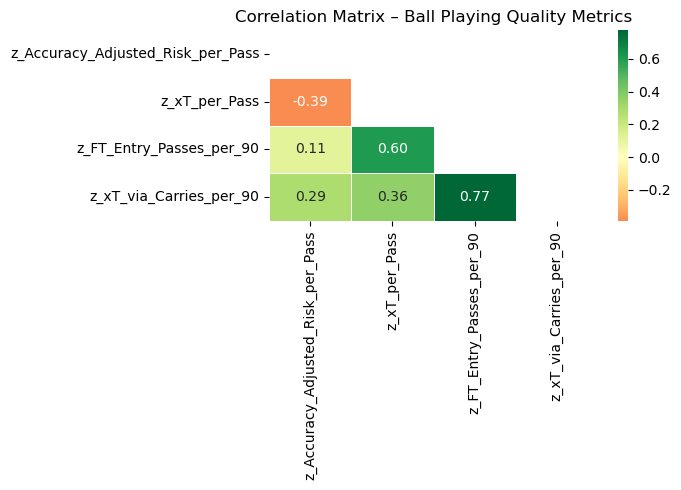

In [137]:
import seaborn as sns

z_cols = ["z_" + c for c in metrics]
corr = z_scores[z_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, mask=mask, annot=True, cmap="RdYlGn",
            center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix – Ball Playing Quality Metrics")
plt.tight_layout()
plt.show()

In [138]:
from classes.visual import DistributionPlot

z_cols = ["z_" + c for c in metrics]

dist_plot = DistributionPlot(
    columns=z_cols,
    labels=["Worse", "Average", "Above Average"]
)
dist_plot.add_title(
    title="Center-Back Ball Playing Quality — Metric Distributions",
    subtitle=f"Based on {len(bp)} players · 2024-25 Premier League · z-scored"
)

dist_plot.add_group_data(
    df_plot=bp,
    plots="",
    names=bp["short_name"],
    legend="All CBs",
    hover="",
    hover_string=""
)

# Highlight V. van Dijk as reference point (player.id = 370)
selected = bp[bp["player.id"] == 370]
if not selected.empty:
    dist_plot.add_data_point(
        ser_plot=selected.iloc[0],
        plots="",
        name=selected["short_name"].iloc[0],
        hover="",
        hover_string=""
    )

dist_plot.fig.show()

### Weights

| Metric | Weight | Reasoning |
|---|---|---|
| `z_Accuracy_Adjusted_Risk_per_Pass` (inverted) | **0.30** | Safe passing under pressure is the foundation of ball-playing ability |
| `z_xT_per_Pass` | **0.30** | Forward-passing tendency — quality per action, style-agnostic |
| `z_FT_Entry_Passes_per_90` | **0.20** | Concrete output: how often the CB unlocks the final third |
| `z_xT_via_Carries_per_90` | **0.20** | Carrying contribution — rewards CBs who progress beyond just passing |

Weights sum to 1.0 and can be adjusted below.

In [139]:
weights = {
    "z_Accuracy_Adjusted_Risk_per_Pass": 0.30,
    "z_xT_per_Pass":                    0.30,
    "z_FT_Entry_Passes_per_90":          0.20,
    "z_xT_via_Carries_per_90":           0.20,
}

bp["Zq_raw"] = sum(bp[m] * w for m, w in weights.items())

# Re-standardise so final score is always centred at 0, std = 1
bp["ball_playing_quality"] = (
    (bp["Zq_raw"] - bp["Zq_raw"].mean()) / bp["Zq_raw"].std()
)

bp.sort_values("ball_playing_quality", ascending=False).head(15)[[
    "short_name", "role", "minutes_played",
    "Accuracy_Adjusted_Risk_per_Pass", "xT_per_Pass",
    "FT_Entry_Passes_per_90", "xT_via_Carries_per_90",
    "ball_playing_quality"
]]

,short_name,role,minutes_played,Accuracy_Adjusted_Risk_per_Pass,xT_per_Pass,FT_Entry_Passes_per_90,xT_via_Carries_per_90,ball_playing_quality
11,Rúben Dias,Defender,2276,0.000119,0.008079,11.072056,0.142034,2.932364
7,M. Akanji,Defender,2031,0.000111,0.008467,8.906942,0.116753,2.517540
33,J. van Hecke,Defender,2968,0.000142,0.010163,8.005391,0.108789,2.404269
5,J. Stones,Defender,572,0.000099,0.007486,6.608392,0.118439,2.110692
3,N. Aké,Defender,687,0.000090,0.007355,6.288210,0.116437,2.100913
9,V. van Dijk,Defender,3330,0.000115,0.008669,8.648649,0.051074,1.752643
58,A. Webster,Defender,909,0.000170,0.009938,8.910891,0.056015,1.612372
28,C. Romero,Defender,1421,0.000136,0.007832,7.980296,0.081306,1.598469
85,M. Senesi,Defender,1133,0.000248,0.013817,8.102383,0.049049,1.575724
74,Dean Huijsen,Defender,2464,0.000202,0.009735,7.451299,0.097896,1.513728


### Saving the Output

We export the Ball Playing Quality table to CSV for use in the Streamlit app and by the agent.

In [140]:
out_path = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data", "PL", "Qualities", "ball_playing_quality.csv"
)
bp.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print(bp.sort_values('ball_playing_quality', ascending=False).head(10)[[
    'short_name', 'ball_playing_quality'
]].to_string(index=False))

Saved → /Users/giorgistsoukaris/Documents/Projects/Football_Science/Twelve_Football/Twelve-GPT-Educational-Giorgis/data/PL/Qualities/ball_playing_quality.csv
  short_name  ball_playing_quality
  Rúben Dias              2.932364
   M. Akanji              2.517540
J. van Hecke              2.404269
   J. Stones              2.110692
      N. Aké              2.100913
 V. van Dijk              1.752643
  A. Webster              1.612372
   C. Romero              1.598469
   M. Senesi              1.575724
Dean Huijsen              1.513728


## CB Quality Radar

In [141]:
from utils.radar import plot_cb_quality_radar

# Change player_id to try any CB in the dataset
fig = plot_cb_quality_radar(
    player_id            = 370,  # Virgil van Dijk
    duel_summary         = duel_summary,
    aerial_duel_summary  = aerial_duel_summary_filt,
    ball_playing_summary = bp,
)
fig.show()

In [142]:
from utils.radar import plot_cb_quality_radar

# Change player_id to try any CB in the dataset
fig = plot_cb_quality_radar(
    player_id            = 415917,  # Virgil van Dijk
    duel_summary         = duel_summary,
    aerial_duel_summary  = aerial_duel_summary_filt,
    ball_playing_summary = bp,
)
fig.show()

In [143]:
from utils.radar import compare_cb_quality_radar

# Change either player_id to compare any two CBs
fig = compare_cb_quality_radar(
    player_id_1          = 370,    # Virgil van Dijk  (white)
    player_id_2          = 415917, # Gabriel Magalhães (yellow)
    duel_summary         = duel_summary,
    aerial_duel_summary  = aerial_duel_summary_filt,
    ball_playing_summary = bp,
)
fig.show()

# Pairing

## CB Pairing Minutes

For every match we know which players played as center-backs and when they were
on the pitch (start / substitution / final whistle).  By computing the **overlap**
between each pair of team-mates' time intervals we can total the minutes each CB
partnership shared on the pitch across the whole season.

**Logic:**
- `t_start = 0` if the player started, otherwise the minute they came on.
- `t_end = sub_out` if the player was substituted off, otherwise 90.
- Overlap = `max(0, min(t_end_A, t_end_B) − max(t_start_A, t_start_B))`
- Pairs are canonical (lower `player_id` first) so (A, B) and (B, A) aggregate together.

In [144]:
minutes_england_df.head(20)

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
0,583656,61,RAMF,Winger,16,1611,5588080,False,0,False,0,0,0,61,61,0,True,364,2024
1,346139,61,AMF,Midfielder,7,1611,5588080,True,1,False,0,0,0,61,61,0,True,364,2024
2,8653,81,RCB,Central Defender,5,1611,5588080,True,1,False,0,0,0,81,81,0,True,364,2024
3,349142,81,RB,Full Back,3,1611,5588080,False,0,False,0,0,0,81,81,0,True,364,2024
4,692544,84,LDMF,Midfielder,37,1611,5588080,False,0,False,0,0,0,84,84,0,True,364,2024
5,344038,90,GK,Goalkeeper,24,1611,5588080,False,0,False,0,0,0,0,90,0,True,364,2024
6,243588,90,CF,Striker,8,1611,5588080,False,0,False,0,0,0,0,90,0,True,364,2024
7,40756,90,RDMF,Midfielder,18,1611,5588080,False,0,False,0,0,0,0,90,0,True,364,2024
8,369589,90,LB,Full Back,20,1611,5588080,False,0,False,0,0,0,0,90,0,True,364,2024
9,488453,90,LCB,Central Defender,6,1611,5588080,False,0,False,0,0,0,0,90,0,True,364,2024


In [145]:
minutes_england_df.columns

Index(['player_id', 'minutes_played', 'position_provider', 'position',
       'jersey_number', 'team_id', 'match_id', 'yellow_card', 'bookings',
       'red_card', 'goals', 'assists', 'sub_in', 'sub_out', 'minutes',
       'own_goals', 'starting', 'competition', 'season'],
      dtype='str')

In [146]:
from itertools import combinations

CB_POSITIONS = {"CB", "LCB", "RCB", "LCB3", "RCB3"}

# ── Build CB interval table ──────────────────────────────────────────────────
cbs = minutes_england_df[minutes_england_df["position_provider"].isin(CB_POSITIONS)].copy()

# t_start: 0 for starters, sub-in minute for substitutes
cbs["t_start"] = cbs.apply(lambda r: 0 if r["starting"] else r["sub_in"], axis=1)
# t_end:   sub-out minute if subbed off, otherwise full 90
cbs["t_end"]   = cbs["sub_out"].where(cbs["sub_out"] > 0, 90)

cbs[["player_id", "minutes_played", "match_id", "team_id", "position_provider",
     "starting", "sub_in", "sub_out", "t_start", "t_end"]].head(10)

,player_id,minutes_played,match_id,team_id,position_provider,starting,sub_in,sub_out,t_start,t_end
2,8653,81,5588080,1611,RCB,True,0,81,0,81
9,488453,90,5588080,1611,LCB,True,0,0,0,90
13,7914,13,5588080,1611,LCB,False,81,0,81,90
14,365443,13,5588080,1611,RCB,False,81,0,81,90
22,447424,90,5588080,1616,LCB,True,0,0,0,90
23,286380,90,5588080,1616,RCB,True,0,0,0,90
37,415917,90,5588082,1609,LCB,True,0,0,0,90
42,578325,90,5588082,1609,RCB,True,0,0,0,90
55,590874,90,5588082,1629,LCB,True,0,0,0,90
56,645877,90,5588082,1629,RCB,True,0,0,0,90


### Computing Pairwise Overlap Per Match

For each (match, team) group we iterate over every pair of CBs and compute
how many minutes they were simultaneously on the pitch.

In [147]:
records = []

for (match_id, team_id), group in cbs.groupby(["match_id", "team_id"]):
    cb_list = group[["player_id", "t_start", "t_end"]].values.tolist()
    for (id_a, s_a, e_a), (id_b, s_b, e_b) in combinations(cb_list, 2):
        overlap = max(0, min(e_a, e_b) - max(s_a, s_b))
        if overlap > 0:
            # Canonical ordering: lower player_id always goes first
            p1, p2 = (id_a, id_b) if id_a < id_b else (id_b, id_a)
            records.append({"player_id_1": p1, "player_id_2": p2, "overlap": overlap})

pairs_raw = pd.DataFrame(records)
print(f"{len(pairs_raw):,} match-level pair observations before aggregation")

1,525 match-level pair observations before aggregation


In [148]:
pairs_raw

,player_id_1,player_id_2,overlap
0,8653,488453,81
1,7914,488453,9
2,365443,488453,9
3,7914,365443,9
4,286380,447424,90
...,...,...,...
1520,62126,590874,86
1521,590874,623641,90
1522,396912,623641,4
1523,396912,590874,4


### Aggregating Across the Season

Sum the per-match overlap and join player names from the reference table.

In [149]:
cb_pairing = (
    pairs_raw
    .groupby(["player_id_1", "player_id_2"], as_index=False)["overlap"]
    .sum()
    .rename(columns={"overlap": "minutes_played_together"})
    .sort_values("minutes_played_together", ascending=False)
    .reset_index(drop=True)
)

# Join readable names
name_map = players_england_df.set_index("player_id")["short_name"]
cb_pairing["player1_name"] = cb_pairing["player_id_1"].map(name_map)
cb_pairing["player2_name"] = cb_pairing["player_id_2"].map(name_map)

# Join ground duel quality score for each player
# duel_summary has a MultiIndex (player.id, player.name) — extract level 0
quality_map = duel_summary["duel_quality"]
quality_map.index = quality_map.index.get_level_values("player.id")
cb_pairing["player1_ground_duel_quality"] = cb_pairing["player_id_1"].map(quality_map)
cb_pairing["player2_ground_duel_quality"] = cb_pairing["player_id_2"].map(quality_map)

cb_pairing = cb_pairing[
    [
        "player_id_1", "player_id_2",
        "player1_name", "player2_name",
        "minutes_played_together",
        "player1_ground_duel_quality", "player2_ground_duel_quality",
    ]
]

print(f"{len(cb_pairing)} unique CB pairs")
cb_pairing.head(20)

305 unique CB pairs


,player_id_1,player_id_2,player1_name,player2_name,minutes_played_together,player1_ground_duel_quality,player2_ground_duel_quality
0,424241,627012,N. Milenković,Murillo,3099,0.639226,0.24646
1,50102,192792,F. Schär,D. Burn,2909,-1.061079,-0.178035
2,397074,504375,M. Guéhi,M. Lacroix,2694,0.780762,0.179846
3,370,393247,V. van Dijk,I. Konaté,2475,1.36018,0.263022
4,240032,549884,J. Bednarek,T. Harwood-Bellis,2252,0.887905,-0.804776
5,415917,578325,Gabriel Magalhaes,W. Saliba,2218,-0.588887,0.537153
6,590703,777938,I. Zabarnyi,Dean Huijsen,2176,0.945072,0.593202
7,145787,447424,J. Andersen,C. Bassey,2174,-0.917334,0.942461
8,9433,604320,J. Tarkowski,J. Branthwaite,2119,0.015719,-0.30204
9,413002,496001,K. Mavropanos,M. Kilman,1925,0.779918,-0.209954


In [150]:
cb_pairing.tail()

,player_id_1,player_id_2,player1_name,player2_name,minutes_played_together,player1_ground_duel_quality,player2_ground_duel_quality
300,364003,730424,S. Bueno,N. Djiga,1,0.184521,NaN
301,62224,240032,R. Fraser,J. Bednarek,1,NaN,0.887905
302,290954,578325,K. Tierney,W. Saliba,1,NaN,0.537153
303,447195,620468,H. Clarke,J. Greaves,1,NaN,0.375144
304,386020,620468,G. Edmundson,J. Greaves,1,NaN,0.375144


In [151]:
cb_pairing

,player_id_1,player_id_2,player1_name,player2_name,minutes_played_together,player1_ground_duel_quality,player2_ground_duel_quality
0,424241,627012,N. Milenković,Murillo,3099,0.639226,0.24646
1,50102,192792,F. Schär,D. Burn,2909,-1.061079,-0.178035
2,397074,504375,M. Guéhi,M. Lacroix,2694,0.780762,0.179846
3,370,393247,V. van Dijk,I. Konaté,2475,1.36018,0.263022
4,240032,549884,J. Bednarek,T. Harwood-Bellis,2252,0.887905,-0.804776
...,...,...,...,...,...,...,...
300,364003,730424,S. Bueno,N. Djiga,1,0.184521,NaN
301,62224,240032,R. Fraser,J. Bednarek,1,NaN,0.887905
302,290954,578325,K. Tierney,W. Saliba,1,NaN,0.537153
303,447195,620468,H. Clarke,J. Greaves,1,NaN,0.375144


### Saving the Output

We export the CB pairing table to CSV for use in the Streamlit app and by the agent.

In [152]:
out_path = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data", "PL", "Qualities", "cb_pairing_minutes.csv"
)
cb_pairing.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print(cb_pairing.head(10).to_string(index=False))

Saved → /Users/giorgistsoukaris/Documents/Projects/Football_Science/Twelve_Football/Twelve-GPT-Educational-Giorgis/data/PL/Qualities/cb_pairing_minutes.csv
 player_id_1  player_id_2      player1_name      player2_name  minutes_played_together player1_ground_duel_quality player2_ground_duel_quality
      424241       627012     N. Milenković           Murillo                     3099                    0.639226                     0.24646
       50102       192792          F. Schär           D. Burn                     2909                   -1.061079                   -0.178035
      397074       504375          M. Guéhi        M. Lacroix                     2694                    0.780762                    0.179846
         370       393247       V. van Dijk         I. Konaté                     2475                     1.36018                    0.263022
      240032       549884       J. Bednarek T. Harwood-Bellis                     2252                    0.887905               